In [95]:
from Bio import SeqIO
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from colorsys import rgb_to_hls, hls_to_rgb  # Using colorsys instead
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import permanova, permdisp  # For multivariate stats


from skbio import DistanceMatrix
from skbio import OrdinationResults
from skbio.stats.ordination import pcoa
from skbio.stats.distance import anosim
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from emperor import Emperor
from os import makedirs
from os.path import join
from upsetplot import from_indicators, from_memberships, from_contents, plot, UpSet
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('future.no_silent_downcasting', True)
warnings.filterwarnings("ignore", category=RuntimeWarning)
from matplotlib.patches import Patch

import re

from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression


import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.anova import AnovaRM

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [78]:
# pip install pandas matplotlib upsetplot

In [11]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1


In [7]:
# === INPUT FILES ===
temecula_gbk = "Temecula1.gbff"
x9a5c_gbk = "9a5c.gbff"
rbh_csv = "9a5c_vs_Temecula1_rbh.csv"
img_9a5c_csv = "annot_comprator_9a5c.csv"
img_temecula_csv = "annot_comprator_Temecula1.csv"
output_file = "final_ortholog_table_with_img.csv"

# === STEP 1: Extract GBFF annotations ===

def extract_protein_annotation(gbk_file):
    data = {}
    for record in SeqIO.parse(gbk_file, "genbank"):
        for feat in record.features:
            if feat.type == "CDS":
                q = feat.qualifiers
                protein_id = q.get("protein_id", [""])[0]
                if protein_id:
                    data[protein_id] = {
                        "locus_tag": q.get("locus_tag", [""])[0],
                        "gene": q.get("gene", [""])[0],
                        "old_locus_tags": ";".join(q.get("old_locus_tag", [])),
                        "product": q.get("product", [""])[0],
                        "location": f"{feat.location.start}..{feat.location.end}",
                        "length": abs(int(feat.location.end) - int(feat.location.start)),
                    }
    return data

print("[1/5] Parsing GBFF files...")

temecula_annot = extract_protein_annotation(temecula_gbk)
x9a5c_annot = extract_protein_annotation(x9a5c_gbk)

# === STEP 2: Load RBH pairs ===

print("[2/5] Loading RBH results...")

rbh_pairs = []
with open(rbh_csv, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rbh_pairs.append((row["9a5c_protein_ID"], row["Temecula1_protein_ID"]))

# === STEP 3: Load IMG CSVs by old_locus_tag → IMG_ID ===

def load_img_annotation(img_csv_path):
    """
    Returns a dict mapping old_locus_tag (e.g., XF_0001) → IMG_ID (e.g., XF9a_00001)
    and description/length as well.
    """
    img_map = {}
    with open(img_csv_path, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            old_tag = row["annot_1.1"]
            img_id = row["annot_3.1"]
            product = row["annot_3.2"]
            length = row["annot_3.3"]
            img_map[old_tag] = {
                "IMG_ID": img_id,
                "IMG_product": product,
                "IMG_length": length
            }
    return img_map

print("[3/5] Loading IMG annotations...")

img9a5c = load_img_annotation(img_9a5c_csv)
imgTem = load_img_annotation(img_temecula_csv)

# === STEP 4: Merge All Annotations ===

print("[4/5] Merging RBH, GBFF, and IMG data...")

merged_rows = []

for prot9a5c, protTem in rbh_pairs:
    d9 = x9a5c_annot.get(prot9a5c, {})
    dt = temecula_annot.get(protTem, {})

    img9 = img9a5c.get(d9.get("old_locus_tags", "").split(";")[-1], {})
    imgT = imgTem.get(dt.get("old_locus_tags", "").split(";")[-1], {})

    merged_rows.append({
        "9a5c_protein_ID": prot9a5c,
        "9a5c_locus_tag": d9.get("locus_tag", ""),
        "9a5c_old_locus_tags": d9.get("old_locus_tags", ""),
        "9a5c_gene": d9.get("gene", ""),
        "9a5c_product_GBFF": d9.get("product", ""),
        "9a5c_IMG_ID": img9.get("IMG_ID", ""),
        "9a5c_product_IMG": img9.get("IMG_product", ""),
        "9a5c_IMG_length": img9.get("IMG_length", ""),

        "Temecula1_protein_ID": protTem,
        "Temecula1_locus_tag": dt.get("locus_tag", ""),
        "Temecula1_old_locus_tags": dt.get("old_locus_tags", ""),
        "Temecula1_gene": dt.get("gene", ""),
        "Temecula1_product_GBFF": dt.get("product", ""),
        "Temecula1_IMG_ID": imgT.get("IMG_ID", ""),
        "Temecula1_product_IMG": imgT.get("IMG_product", ""),
        "Temecula1_IMG_length": imgT.get("IMG_length", "")
    })

# === STEP 5: Save Final Table ===

print(f"[5/5] Writing output to: {output_file}")

with open(output_file, "w", newline="") as out:
    writer = csv.DictWriter(out, fieldnames=merged_rows[0].keys())
    writer.writeheader()
    writer.writerows(merged_rows)

print(f"[✓] Done! Final table: {output_file}")

[1/5] Parsing GBFF files...
[2/5] Loading RBH results...
[3/5] Loading IMG annotations...
[4/5] Merging RBH, GBFF, and IMG data...
[5/5] Writing output to: final_ortholog_table_with_img.csv
[✓] Done! Final table: final_ortholog_table_with_img.csv


In [45]:
transcriptome_pcoa = pd.read_csv('matrix_9a5c_Temecula1.csv', sep=";", index_col=0)
transcriptome_pcoa

,9a_PIM6_1d_1,9a_PIM6_1d_2,9a_PIM6_1d_3,9a_PIM6_3d_1,9a_PIM6_3d_2,9a_PIM6_3d_3,9a_PWG_3d_1,9a_PWG_3d_2,9a_PWG_3d_3,9a_PWG_10d_1,...,Tem1_PIM6_1d_3,Tem1_PIM6_3d_1,Tem1_PIM6_3d_2,Tem1_PIM6_3d_3,Tem1_PWG_3d_1,Tem1_PWG_3d_2,Tem1_PWG_3d_3,Tem1_PWG_7d_1,Tem1_PWG_7d_2,Tem1_PWG_7d_3
unified_gene_name,,,,,,,,,,,,,,,,,,,,,
XF9a_00002_XFTem_00002,168.72,124.57,254.45,131.62,147.13,189.71,627.17,1013.30,687.01,193.04,...,676.16,100.57,179.41,249.98,707.45,759.74,994.92,149.14,28.71,427.79
XF9a_00003_XFTem_00003,115.45,58.91,160.66,99.69,118.95,147.88,172.56,372.77,368.69,125.23,...,311.44,37.61,79.33,97.99,173.15,200.14,282.11,47.22,6.33,134.80
XF9a_00005_XFTem_00004,350.30,188.09,652.72,271.52,330.03,282.18,394.95,606.04,630.23,223.31,...,649.01,150.89,205.51,204.69,354.16,403.95,593.16,204.73,46.79,272.14
XF9a_00007_XFTem_00006,62.36,65.56,142.67,101.77,145.08,110.59,117.44,137.58,125.09,76.41,...,175.77,50.89,64.83,75.20,95.43,118.59,145.74,35.28,5.96,56.91
XF9a_00008_XFTem_00007,224.70,130.54,347.00,143.83,159.94,183.47,479.94,463.26,516.79,136.72,...,581.03,228.42,379.04,421.62,506.73,638.28,663.07,133.87,13.03,370.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XF9a_02621_XFTem_02447,221.83,95.34,227.96,182.77,275.24,306.58,239.35,471.03,489.18,260.95,...,69.38,19.29,53.97,79.09,68.48,73.03,114.41,18.39,9.57,64.42
XF9a_02638_XFTem_02476,47.74,26.79,112.84,68.01,98.30,78.90,39.33,66.73,96.42,31.22,...,134.86,39.82,57.93,69.37,40.24,66.46,81.76,19.55,6.99,36.45
XF9a_02639_XFTem_02477,138.98,93.51,259.89,155.79,177.67,160.88,170.27,285.70,236.41,113.86,...,328.48,111.20,164.02,198.07,128.87,149.86,200.17,119.18,25.46,143.33


In [46]:
transcriptome_pcoa_t = transcriptome_pcoa.transpose()
transcriptome_pcoa_t

unified_gene_name,XF9a_00002_XFTem_00002,XF9a_00003_XFTem_00003,XF9a_00005_XFTem_00004,XF9a_00007_XFTem_00006,XF9a_00008_XFTem_00007,XF9a_00009_XFTem_00008,XF9a_00010_XFTem_00009,XF9a_00011_XFTem_00010,XF9a_00012_XFTem_00011,XF9a_00013_XFTem_00012,...,XF9a_02603_XFTem_02437,XF9a_02604_XFTem_02438,XF9a_02611_XFTem_02445,XF9a_02612_XFTem_02446,XF9a_02617_XFTem_01438,XF9a_02621_XFTem_02447,XF9a_02638_XFTem_02476,XF9a_02639_XFTem_02477,XF9a_02641_XFTem_02478,XF9a_02642_XFTem_02479
9a_PIM6_1d_1,168.72,115.45,350.30,62.36,224.70,62.37,646.18,269.95,173.70,24.93,...,17.61,1633.74,43.06,82.12,3.28,221.83,47.74,138.98,191.89,501.14
9a_PIM6_1d_2,124.57,58.91,188.09,65.56,130.54,53.88,460.15,159.25,109.27,14.93,...,13.35,954.25,33.48,60.17,2.29,95.34,26.79,93.51,134.06,270.67
9a_PIM6_1d_3,254.45,160.66,652.72,142.67,347.00,198.67,804.89,483.18,499.09,57.11,...,33.82,2166.64,88.51,147.84,11.55,227.96,112.84,259.89,378.95,637.20
9a_PIM6_3d_1,131.62,99.69,271.52,101.77,143.83,168.49,316.13,239.70,225.52,45.71,...,32.95,744.03,88.31,217.21,11.64,182.77,68.01,155.79,124.27,252.60
9a_PIM6_3d_2,147.13,118.95,330.03,145.08,159.94,239.50,385.62,263.57,269.92,67.72,...,46.95,850.70,102.70,231.81,13.65,275.24,98.30,177.67,165.61,353.62
9a_PIM6_3d_3,189.71,147.88,282.18,110.59,183.47,239.31,346.29,230.55,241.71,45.26,...,37.88,1099.78,120.12,169.81,28.43,306.58,78.90,160.88,143.58,274.41
9a_PWG_3d_1,627.17,172.56,394.95,117.44,479.94,82.39,1634.04,469.54,254.79,19.42,...,18.37,3240.39,145.06,73.42,4.03,239.35,39.33,170.27,180.23,344.18
9a_PWG_3d_2,1013.30,372.77,606.04,137.58,463.26,126.55,954.13,467.04,433.38,25.19,...,18.22,1443.20,30.37,114.50,7.42,471.03,66.73,285.70,535.16,1462.29
9a_PWG_3d_3,687.01,368.69,630.23,125.09,516.79,235.93,1280.37,675.14,795.32,46.11,...,49.67,2677.68,135.48,223.65,14.93,489.18,96.42,236.41,283.69,429.32
9a_PWG_10d_1,193.04,125.23,223.31,76.41,136.72,73.38,274.80,289.32,184.50,15.88,...,20.68,594.05,79.76,54.77,8.23,260.95,31.22,113.86,129.39,189.92


In [47]:
pairwise = pd.DataFrame(
    squareform(pdist(transcriptome_pcoa_t)),
    columns = transcriptome_pcoa_t.index,
    index = transcriptome_pcoa_t.index)

pairwise

,9a_PIM6_1d_1,9a_PIM6_1d_2,9a_PIM6_1d_3,9a_PIM6_3d_1,9a_PIM6_3d_2,9a_PIM6_3d_3,9a_PWG_3d_1,9a_PWG_3d_2,9a_PWG_3d_3,9a_PWG_10d_1,...,Tem1_PIM6_1d_3,Tem1_PIM6_3d_1,Tem1_PIM6_3d_2,Tem1_PIM6_3d_3,Tem1_PWG_3d_1,Tem1_PWG_3d_2,Tem1_PWG_3d_3,Tem1_PWG_7d_1,Tem1_PWG_7d_2,Tem1_PWG_7d_3
9a_PIM6_1d_1,0.000000,23597.293633,16641.425645,28539.731340,27668.730273,26050.585620,43681.993717,32390.531605,26884.011467,28514.034720,...,21242.492010,31128.401970,31407.051241,39628.447910,33206.319580,32786.681569,40925.718925,29674.648286,34702.292970,22602.406366
9a_PIM6_1d_2,23597.293633,0.000000,21602.057775,9994.109228,15535.637452,13400.192077,55530.660717,39333.465531,35040.538462,7742.676514,...,35994.892855,12234.178410,15860.913477,27547.273034,42370.101941,39504.506598,48215.451464,11585.246829,11979.585167,22206.401066
9a_PIM6_1d_3,16641.425645,21602.057775,0.000000,23887.466900,23419.976587,21951.938945,52498.860670,37103.796317,22876.350905,25114.929112,...,23083.561637,24927.313622,25425.541746,33638.722189,36057.513802,27955.609095,34288.718981,26668.445992,31419.597978,20827.901300
9a_PIM6_3d_1,28539.731340,9994.109228,23887.466900,0.000000,7667.061925,6671.732021,60435.765896,42961.178509,35858.398377,8946.337582,...,37737.318603,9663.778025,12480.630470,24938.513753,45115.707460,40611.403804,48752.567771,13454.556033,12059.276524,24543.123745
9a_PIM6_3d_2,27668.730273,15535.637452,23419.976587,7667.061925,0.000000,4103.662468,60643.123354,43231.369596,34471.602232,14914.659268,...,34991.252694,14735.081661,15260.559241,26502.311724,44406.565488,39809.861708,47387.006202,18206.024988,18657.242320,25064.220246
9a_PIM6_3d_3,26050.585620,13400.192077,21951.938945,6671.732021,4103.662468,0.000000,59643.281827,42648.579999,32921.618757,13530.705451,...,34172.066878,13500.774949,14764.898975,26259.166350,43779.923052,38460.710741,46227.590657,17328.427861,17183.252077,23949.957256
9a_PWG_3d_1,43681.993717,55530.660717,52498.860670,60435.765896,60643.123354,59643.281827,0.000000,34037.221697,45741.955807,56832.116173,...,50963.020191,62170.665210,61117.757246,65645.750710,34262.657245,47478.047330,55918.800725,56845.058819,65279.985204,42924.328152
9a_PWG_3d_2,32390.531605,39333.465531,37103.796317,42961.178509,43231.369596,42648.579999,34037.221697,0.000000,33520.501069,41230.573941,...,36131.147846,45151.032572,43682.705049,48549.491181,20831.877529,35126.151105,43440.729956,41085.422959,48839.126540,29835.431819
9a_PWG_3d_3,26884.011467,35040.538462,22876.350905,35858.398377,34471.602232,32921.618757,45741.955807,33520.501069,0.000000,36245.249180,...,26262.020307,37346.465808,36234.423664,41551.475031,29276.793394,18575.744642,24564.350936,38342.967866,44066.883654,25006.224934
9a_PWG_10d_1,28514.034720,7742.676514,25114.929112,8946.337582,14914.659268,13530.705451,56832.116173,41230.573941,36245.249180,0.000000,...,39558.056305,10734.386848,14073.263569,25863.932932,44101.688892,40818.668796,49357.997182,8810.466405,10741.586986,22820.911050


In [48]:
dm = DistanceMatrix(pairwise)

In [49]:
dm

In [51]:
metadata_all_samples_transcriptome = {
     '0': {'sample': '9a_PIM6_1d_1'},
     '1': {'sample': '9a_PIM6_1d_2'},
     '2': {'sample': '9a_PIM6_1d_3'},
     '3': {'sample': '9a_PIM6_3d_1'},
     '4': {'sample': '9a_PIM6_3d_2'},
     '5': {'sample': '9a_PIM6_3d_3'},
     '6': {'sample': '9a_PWG_3d_1'},
     '7': {'sample': '9a_PWG_3d_2'},
     '8': {'sample': '9a_PWG_3d_3'},
     '9': {'sample': '9a_PWG_10d_1'},
     '10': {'sample': '9a_PWG_10d_2'},
     '11': {'sample': '9a_PWG_10d_3'},
     '12': {'sample': 'Tem1_PIM6_1d_1'},
     '13': {'sample': 'Tem1_PIM6_1d_2'},
     '14': {'sample': 'Tem1_PIM6_1d_3'},
     '15': {'sample': 'Tem1_PIM6_3d_1'},
     '16': {'sample': 'Tem1_PIM6_3d_2'},
     '17': {'sample': 'Tem1_PIM6_3d_3'},
     '18': {'sample': 'Tem1_PWG_3d_1'},
     '19': {'sample': 'Tem1_PWG_3d_2'},
     '20': {'sample': 'Tem1_PWG_3d_3'},
     '21': {'sample': 'Tem1_PWG_7d_1'},
     '22': {'sample': 'Tem1_PWG_7d_2'},
     '23': {'sample': 'Tem1_PWG_7d_3'}}
df_metadata_all_samples_transcriptome = pd.DataFrame.from_dict(metadata_all_samples_transcriptome, orient='index')
df_metadata_all_samples_transcriptome

,sample
0,9a_PIM6_1d_1
1,9a_PIM6_1d_2
2,9a_PIM6_1d_3
3,9a_PIM6_3d_1
4,9a_PIM6_3d_2
5,9a_PIM6_3d_3
6,9a_PWG_3d_1
7,9a_PWG_3d_2
8,9a_PWG_3d_3
9,9a_PWG_10d_1


In [52]:
pcoa_results_all_samples_transcriptome = pcoa(dm)
pcoa_results_all_samples_transcriptome

In [54]:
all_samples_transcriptome_pcoa = Emperor(pcoa_results_all_samples_transcriptome, df_metadata_all_samples_transcriptome, remote='.')
all_samples_transcriptome_pcoa

/home/oseiasfeitosajr/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/emperor/util.py:283: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if coords_pct[0] < 1.0 and not pct_variation_below_one:


In [55]:
output_folder = 'all_samples_transcriptome' # new folder where data will be saved

# create an output directory
makedirs(output_folder, exist_ok=True)

with open(join(output_folder, 'index.html'), 'w') as f:
    f.write(all_samples_transcriptome_pcoa.make_emperor(standalone=True))
    all_samples_transcriptome_pcoa.copy_support_files(output_folder)

/home/oseiasfeitosajr/.local/share/pipx/venvs/notebook/lib/python3.12/site-packages/emperor/util.py:283: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if coords_pct[0] < 1.0 and not pct_variation_below_one:


In [57]:
grouping = ['9a_PIM6_1d','9a_PIM6_1d','9a_PIM6_1d','9a_PIM6_3d','9a_PIM6_3d','9a_PIM6_3d','9a_PWG_3d','9a_PWG_3d','9a_PWG_3d','9a_PWG_10d','9a_PWG_10d','9a_PWG_10d','Tem1_PIM6_1d','Tem1_PIM6_1d','Tem1_PIM6_1d','Tem1_PIM6_3d','Tem1_PIM6_3d','Tem1_PIM6_3d','Tem1_PWG_3d','Tem1_PWG_3d','Tem1_PWG_3d','Tem1_PWG_7d','Tem1_PWG_7d','Tem1_PWG_7d']

In [58]:
permanova_test_pcoa = permanova(dm, grouping)
permanova_test_pcoa

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      24
number of groups                  8
test statistic             4.270055
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

In [60]:
permdisp_test_pcoa = permdisp(dm, grouping, permutations=9999)
permdisp_test_pcoa

method name               PERMDISP
test statistic name        F-value
sample size                     24
number of groups                 8
test statistic            1.446039
p-value                     0.0656
number of permutations        9999
Name: PERMDISP results, dtype: object

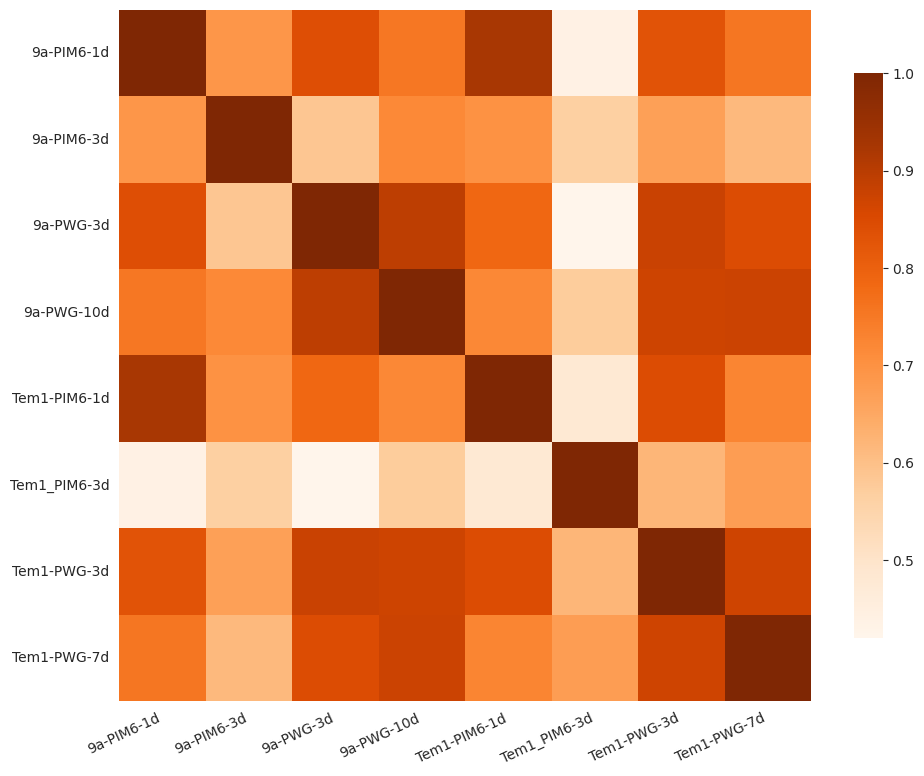

In [26]:
# Define the row and column labels
labels = [
    '9a-PIM6-1d',
    '9a-PIM6-3d',
    '9a-PWG-3d',
    '9a-PWG-10d',
    'Tem1-PIM6-1d',
    'Tem1_PIM6-3d',
    'Tem1-PWG-3d',
    'Tem1-PWG-7d'
]

# Define the correlation matrix as a list of lists
data = [
    [1.0000, 0.6911, 0.8404, 0.7551, 0.9251, 0.4388, 0.8317, 0.7574],
    [0.6911, 1.0000, 0.5873, 0.7171, 0.6994, 0.5657, 0.6680, 0.6135],
    [0.8404, 0.5873, 1.0000, 0.8943, 0.7856, 0.4201, 0.8756, 0.8442],
    [0.7551, 0.7171, 0.8943, 1.0000, 0.7204, 0.5740, 0.8719, 0.8738],
    [0.9251, 0.6994, 0.7856, 0.7204, 1.0000, 0.4794, 0.8443, 0.7280],
    [0.4388, 0.5657, 0.4201, 0.5740, 0.4794, 1.0000, 0.6205, 0.6749],
    [0.8317, 0.6680, 0.8756, 0.8719, 0.8443, 0.6205, 1.0000, 0.8701],
    [0.7574, 0.6135, 0.8442, 0.8738, 0.7280, 0.6749, 0.8701, 1.0000]
]

# Create a DataFrame
df = pd.DataFrame(data, index=labels, columns=labels)


# Create a heatmap
plt.figure(figsize=(10, 8))
vmin = np.min(df.values)
vmax = np.max(df.values)
g= sns.heatmap(df, cmap='Oranges', vmin=vmin, vmax=vmax, annot=False, fmt=".4f", square=True, linewidths=.0, cbar_kws={'shrink': .8})
g.set_xticklabels(labels, rotation=25, ha='right')
# plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.savefig("pearson_heatmap_9a_Tem1.tiff", dpi=600, format='tiff')
plt.show()

/tmp/ipykernel_1836/2800035197.py:63: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  g.fig.tight_layout()


<Figure size 1000x800 with 0 Axes>

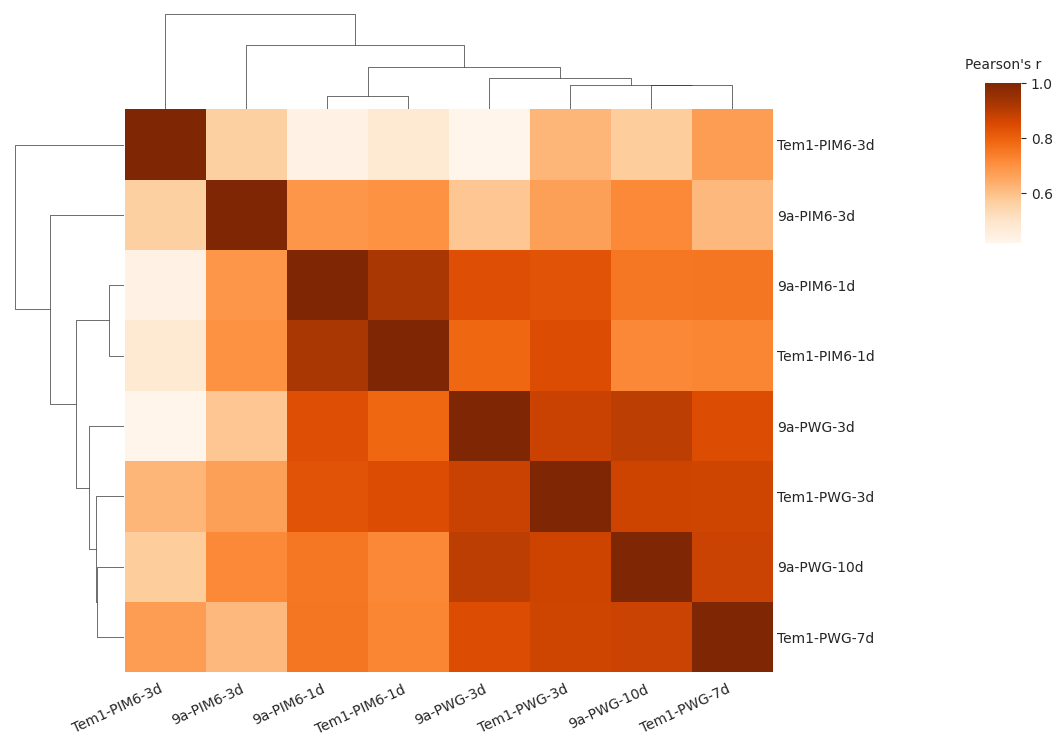

In [93]:
# Define the row and column labels
labels = [
    '9a-PIM6-1d',
    '9a-PIM6-3d',
    '9a-PWG-3d',
    '9a-PWG-10d',
    'Tem1-PIM6-1d',
    'Tem1-PIM6-3d',
    'Tem1-PWG-3d',
    'Tem1-PWG-7d'
]

# Define the correlation matrix as a list of lists
data = [
    [1.0000, 0.6911, 0.8404, 0.7551, 0.9251, 0.4388, 0.8317, 0.7574],
    [0.6911, 1.0000, 0.5873, 0.7171, 0.6994, 0.5657, 0.6680, 0.6135],
    [0.8404, 0.5873, 1.0000, 0.8943, 0.7856, 0.4201, 0.8756, 0.8442],
    [0.7551, 0.7171, 0.8943, 1.0000, 0.7204, 0.5740, 0.8719, 0.8738],
    [0.9251, 0.6994, 0.7856, 0.7204, 1.0000, 0.4794, 0.8443, 0.7280],
    [0.4388, 0.5657, 0.4201, 0.5740, 0.4794, 1.0000, 0.6205, 0.6749],
    [0.8317, 0.6680, 0.8756, 0.8719, 0.8443, 0.6205, 1.0000, 0.8701],
    [0.7574, 0.6135, 0.8442, 0.8738, 0.7280, 0.6749, 0.8701, 1.0000]
]

# Create a DataFrame
df = pd.DataFrame(data, index=labels, columns=labels)
# print(df)

# Create a heatmap
plt.figure(figsize=(10, 8))
vmin = np.min(df.values)
vmax = np.max(df.values)
# g= sns.heatmap(df, cmap='Oranges', vmin=vmin, vmax=vmax, annot=False, fmt=".4f", square=True, linewidths=.0, cbar_kws={'shrink': .8})
# g.set_xticklabels(labels, rotation=25, ha='right')
# plt.title('Pearson Correlation Heatmap')


# plt.show()


g= sns.clustermap(df,
               cmap='Oranges',
               vmin=vmin, vmax=vmax,
               figsize=(9, 8),
               annot=False,
               linewidths=0.0,
               cbar_kws={'shrink': 0.8},
               dendrogram_ratio=(0.15, 0.15),
               metric='euclidean',   # or 'correlation'
               colors_ratio=0.02,   
               method='average')     # clustering method
# g.ax_heatmap.tick_params(axis='x',labels, rotation=25, ha='right')
g.ax_heatmap.set_xticklabels(g.data.columns[g.dendrogram_col.reordered_ind], 
                             rotation=25, ha='right')
g.ax_heatmap.tick_params(axis='y', length=0)  # remove tick marks
# Access the colorbar axis
cbar_ax = g.ax_cbar
# Move it anywhere using normalized figure coordinates (left, bottom, width, height)
cbar_ax.set_position([1.1, 0.69, 0.04, 0.2])
cbar_ax.set_title("Pearson's r", fontsize=10, pad=10)


g.fig.tight_layout()
# plt.suptitle("Hierarchical Clustering of Transcriptomic Correlations", fontsize=14)
# plt.savefig("pearson_heatmap_9a_Tem1.tiff", dpi=600, format='tiff')
g.savefig("pearson_clustermap_9a_Tem1.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

In [89]:
df

,9a-PIM6-1d,9a-PIM6-3d,9a-PWG-3d,9a-PWG-10d,Tem1-PIM6-1d,Tem1_PIM6-3d,Tem1-PWG-3d,Tem1-PWG-7d
9a-PIM6-1d,1.0000,0.6911,0.8404,0.7551,0.9251,0.4388,0.8317,0.7574
9a-PIM6-3d,0.6911,1.0000,0.5873,0.7171,0.6994,0.5657,0.6680,0.6135
9a-PWG-3d,0.8404,0.5873,1.0000,0.8943,0.7856,0.4201,0.8756,0.8442
9a-PWG-10d,0.7551,0.7171,0.8943,1.0000,0.7204,0.5740,0.8719,0.8738
Tem1-PIM6-1d,0.9251,0.6994,0.7856,0.7204,1.0000,0.4794,0.8443,0.7280
Tem1_PIM6-3d,0.4388,0.5657,0.4201,0.5740,0.4794,1.0000,0.6205,0.6749
Tem1-PWG-3d,0.8317,0.6680,0.8756,0.8719,0.8443,0.6205,1.0000,0.8701
Tem1-PWG-7d,0.7574,0.6135,0.8442,0.8738,0.7280,0.6749,0.8701,1.0000


In [106]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM


In [9]:
# 1. Load the two TPM‐average tables and the dictionary
df_9a = pd.read_csv("table_9a_avg_tpm.csv", sep="\t")
df_tem = pd.read_csv("table_tem_avg_tpm.csv", sep="\t")
map_dict = pd.read_csv("gene_dictionary.csv", sep="\t")

# 2. Create unified gene IDs in the dictionary
map_dict["unified_gene_name"] = (
    map_dict["9a5c_IMG_ID"].fillna("") + "_" + map_dict["Temecula1_IMG_ID"].fillna("")
).str.strip("_")

# 3. Build lookup maps
dict_9a = map_dict.set_index("9a5c_IMG_ID")["unified_gene_name"].to_dict()
dict_tem = map_dict.set_index("Temecula1_IMG_ID")["unified_gene_name"].to_dict()

# 4. Assign unified names (and tag exclusives)
df_9a["unified_gene_name"] = (
    df_9a["Name"].map(dict_9a)
             .fillna(df_9a["Name"] + "_9a_only")
)
df_tem["unified_gene_name"] = (
    df_tem["Name"].map(dict_tem)
              .fillna(df_tem["Name"] + "_Tem_only")
)

# 5. Convert comma-decimals to floats
for df in (df_9a, df_tem):
    for col in df.columns:
        if col not in ("Name", "unified_gene_name"):
            df[col] = (
                df[col]
                  .astype(str)
                  .str.replace(",", ".")
                  .astype(float)
            )

# 6. Drop the original “Name” column
df_9a = df_9a.drop(columns="Name")
df_tem = df_tem.drop(columns="Name")

# 7. Prefix each TPM column with strain label
rename_9a = {c: f"9a_{c.replace(' ', '_')}" for c in df_9a.columns if c!="unified_gene_name"}
rename_tem = {c: f"Tem1_{c.replace(' ', '_')}" for c in df_tem.columns if c!="unified_gene_name"}
df_9a = df_9a.rename(columns=rename_9a)
df_tem = df_tem.rename(columns=rename_tem)

# 8. Merge into one wide table
df_wide = pd.merge(
    df_9a,
    df_tem,
    on="unified_gene_name",
    how="outer"
)

# 9. Fill missing TPM with 0
for col in df_wide.columns:
    if col != "unified_gene_name":
        df_wide[col] = df_wide[col].fillna(0)

# 10. Write out for upset
df_wide.to_csv("upset_input_with_exclusives.csv", index=False)

print("Written upset_input_with_exclusives.csv")
print(df_wide.head())

Written upset_input_with_exclusives.csv
   9a_PIM6_-_1d  9a_PIM6_-_3d  9a_PWG_-_3d  9a_PWG_-_10d unified_gene_name  \
0           0.0          0.00          0.0          0.00     16S_1_9a_only   
1           0.0          0.00          0.0          0.00    16S_1_Tem_only   
2           0.0          0.09          0.0          0.02     16S_2_9a_only   
3           0.0          0.00          0.0          0.00    16S_2_Tem_only   
4           0.0          0.00          0.0          0.00     23S_1_9a_only   

   Tem1_PIM6_-_1d  Tem1_PIM6_-_3d  Tem1_PWG_-_3d  Tem1_PWG_-_7d_-_1  
0             0.0            0.00           0.00               0.00  
1             0.1            0.17           0.11               0.00  
2             0.0            0.00           0.00               0.00  
3             0.0            0.00           0.00               0.08  
4             0.0            0.00           0.00               0.00  


Number of axes in the figure: 4
Axes 0:
  Title: 
  Number of patches: 8
  Legend: None
Axes 1:
  Title: 
  Number of patches: 0
  Legend: None
Axes 2:
  Title: 
  Number of patches: 8
  Legend: None
Axes 3:
  Title: 
  Number of patches: 44
  Legend: None


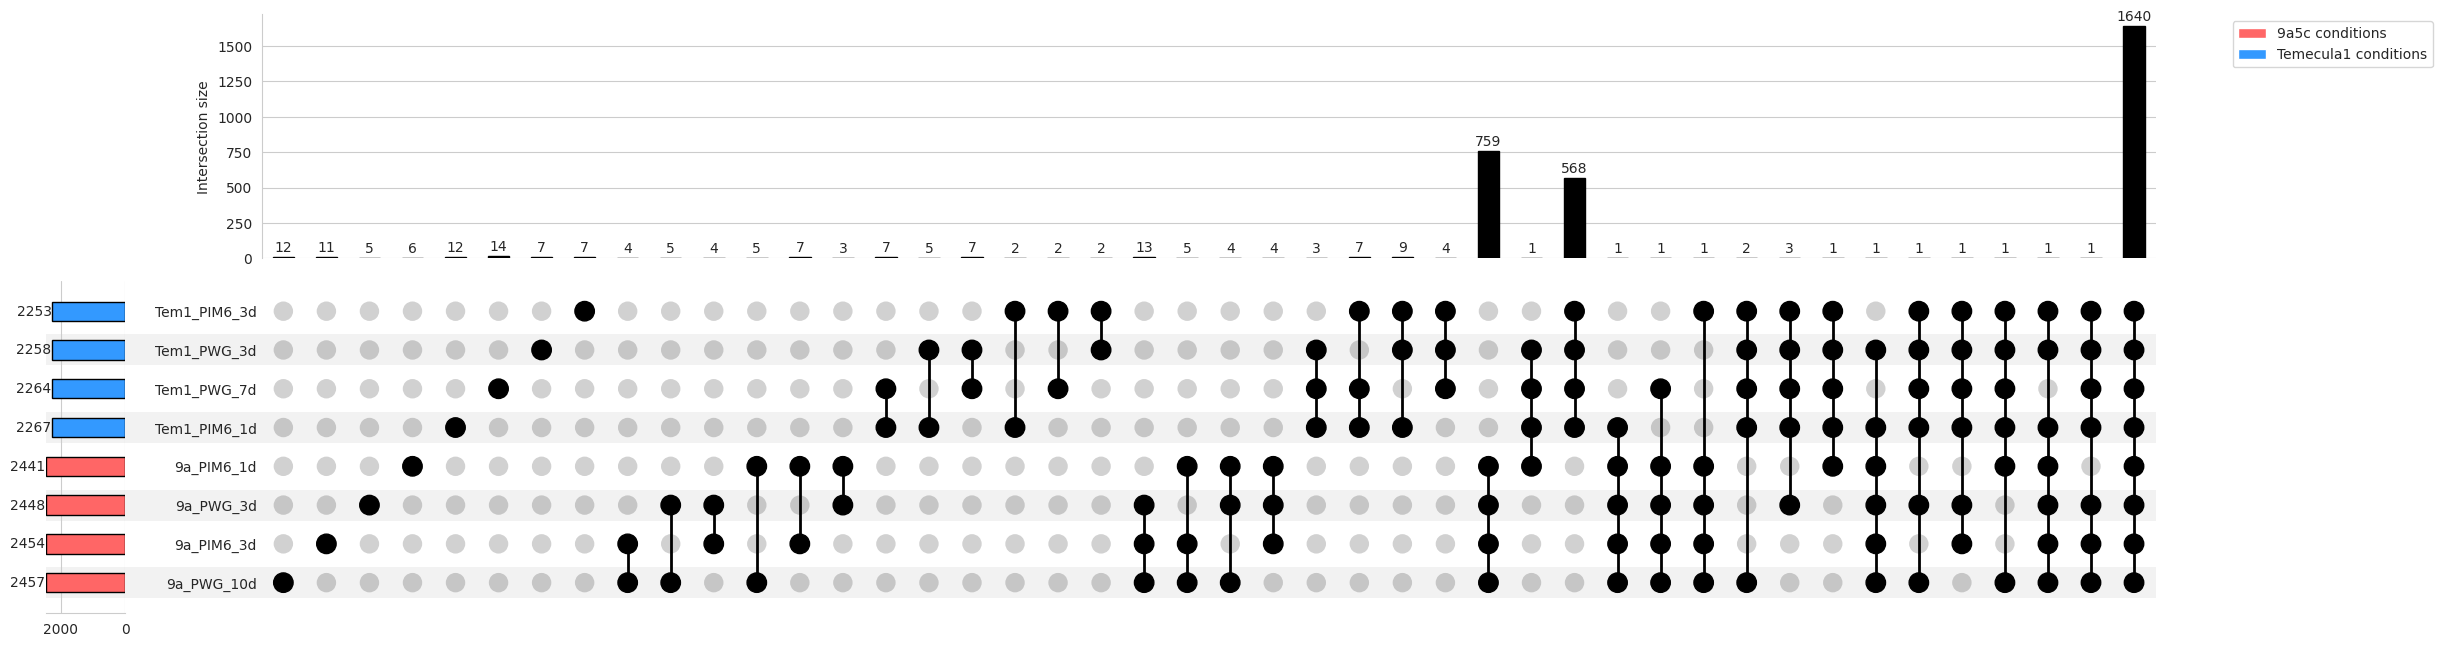

In [107]:
# import pandas as pd
# from upsetplot import from_contents, UpSet
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch
# import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Load the data
df = pd.read_csv("upset_input_with_exclusives.csv")

# Convert TPM values to binary (0 or 1)
df_bool = (df.set_index("unified_gene_name") > 0).astype(bool)

# Convert to the format needed for from_contents
data_for_plot = {}
for col in df_bool.columns:
    presence = df_bool[df_bool[col]].index.tolist()
    data_for_plot[col] = set(presence)

# Function to determine the color based on the intersection set
def get_color_for_intersection(label):
    if not label:
        return "lightgray"  # Empty intersection

    # Split the label string to get individual conditions
    conditions = [item.strip() for item in label.split("&") if item.strip()]

    if not conditions:
        return "lightgray"

    # Check if all conditions are from 9a5c
    if all(cond.startswith("9a_") for cond in conditions):
        return "#3399FF"  # Blue for 9a5c only

    # Check if all conditions are from Temecula1
    elif all(cond.startswith("Tem1_") for cond in conditions):
        return "#FF6666"  # Red for Temecula1 only

    # Otherwise, it's a mixed intersection
    return "gray"

# Create UpSet object
upset_data = from_contents(data_for_plot)

# Create the plot first
upset = UpSet(
    upset_data,
    sort_by="degree",
    show_counts=True,
    element_size=40
)

# Get the figure and axes after creating the plot
fig_dict = upset.plot()  # This returns a dictionary of plot elements
fig = plt.gcf()  # Get the current figure

# Now we need to get the actual axes from the figure
intersections_ax = None
matrix_ax = None

# Find the right axes in our figure
for ax in fig.axes:
    # Try to identify the intersections axis by its label format
    if hasattr(ax, 'get_ylabel') and ax.get_ylabel() == 'Intersection Size':
        intersections_ax = ax
    # Try to identify the matrix axis by looking for condition names
    elif hasattr(ax, 'get_yticklabels'):
        # Check if any label starts with our condition prefixes
        labels = [label.get_text() for label in ax.get_yticklabels() if hasattr(label, 'get_text')]
        if any(label.startswith("9a_") or label.startswith("Tem1_") for label in labels):
            matrix_ax = ax

# Print debug information about the axes
print("Number of axes in the figure:", len(fig.axes))
for i, ax in enumerate(fig.axes):
    print(f"Axes {i}:")
    print(f"  Title: {getattr(ax, 'get_title', lambda: 'None')()}")
    print(f"  Number of patches: {len(ax.patches) if hasattr(ax, 'patches') else 0}")
    if hasattr(ax, 'get_legend'):
        print(f"  Legend: {ax.get_legend()}")

# Color the intersection bars if we found the axis
if intersections_ax:
    for bar in intersections_ax.patches:
        label = bar.get_label()
        color = get_color_for_intersection(label)
        bar.set_facecolor(color)

# Color the condition bars if we found the matrix axis
if matrix_ax:
    # Define colors for each condition based on strain
    condition_colors = {}
    for cond in df_bool.columns:
        if cond.startswith("9a_"):
            condition_colors[cond] = "#FF6666"  # Blue for 9a5c conditions
        else:  # Temecula1 conditions
            condition_colors[cond] = "#3399FF"  # Red for Temecula1 conditions

    # Get condition labels from the y-axis
    if hasattr(matrix_ax, 'get_yticklabels'):
        condition_order = [label.get_text() for label in matrix_ax.get_yticklabels()]

        # Color the matrix bars
        for i, cond in enumerate(condition_order):
            if i < len(matrix_ax.patches):
                try:
                    matrix_ax.patches[i].set_facecolor(condition_colors.get(cond, "gray"))
                except Exception as e:
                    print(f"Error coloring patch {i} for condition {cond}: {e}")

# Add legend
legend_elems = [
    Patch(facecolor="#FF6666", label="9a5c conditions"),
    Patch(facecolor="#3399FF", label="Temecula1 conditions"),
]

# Add legend to the intersection plot
# intersections_ax.legend(handles=legend_elems, loc="upper right", bbox_to_anchor=(1.3, 1))
ax.legend(handles=legend_elems, loc="upper right", bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.savefig("upset_plot_color_strain.png", dpi=600, bbox_inches='tight')
plt.show()

In [3]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM


<Figure size 1200x800 with 0 Axes>

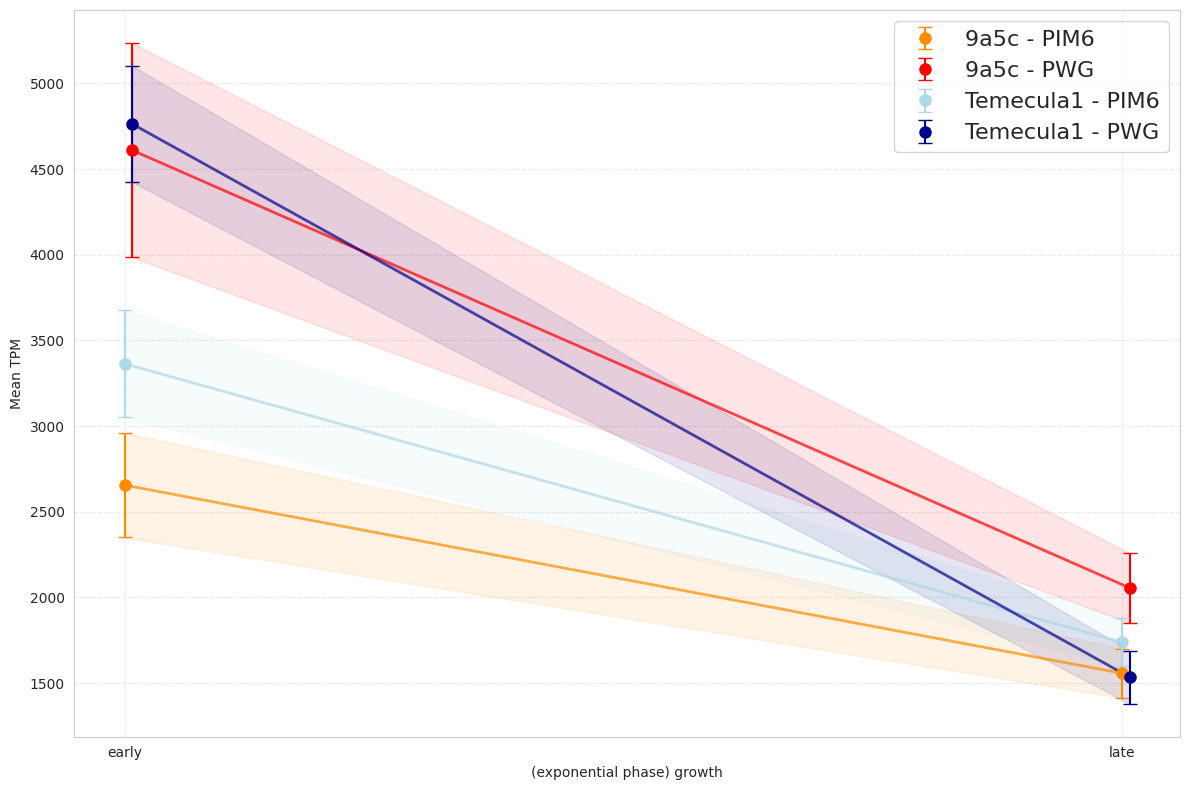

In [240]:
# def process_data(top_n_genes=100, alpha=0.05, require_full_coverage=True):
#     # Load the data files
#     df_9a = pd.read_csv("table_9a_b4_avg_tpm.csv", sep="\t")
#     df_tem = pd.read_csv("table_tem_b4_avg_tpm.csv", sep="\t")
#     dict_df = pd.read_csv("gene_dictionary.csv", sep="\t")

#     # Convert numbers
#     def convert_number(x):
#         if isinstance(x, str):
#             return float(x.replace(',', '.'))
#         return float(x)

#     # Map genes between strains
#     dict_9a = dict_df.set_index('9a5c_IMG_ID')['Temecula1_IMG_ID'].dropna().to_dict()
#     dict_tem = dict_df.set_index('Temecula1_IMG_ID')['9a5c_IMG_ID'].dropna().to_dict()

#     shared_genes = set()
#     for g in df_9a['Name']:
#         if g in dict_9a:
#             shared_genes |= {g, dict_9a[g]}
#     for g in df_tem['Name']:
#         if g in dict_tem:
#             shared_genes |= {g, dict_tem[g]}

#     # Condition maps
#     condition_map_9a = {
#         'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
#         'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
#         'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
#         'PWG - late' : ['PWG - 10d - 1', 'PWG - 10d - 2', 'PWG - 10d - 3']
#     }
#     condition_map_tem = {
#         'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
#         'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
#         'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
#         'PWG - late' : ['PWG - 7d - 1', 'PWG - 7d - 2', 'PWG - 7d - 3']
#     }

#     # Initial top genes by mean TPM
#     def get_top_genes(df, condition_map, shared, n):
#         stats = []
#         for gene in shared:
#             vals = []
#             for cols in condition_map.values():
#                 if gene in df['Name'].values:
#                     row = df[df['Name']==gene].iloc[0]
#                     vals += [convert_number(row[c]) for c in cols if c in df.columns]
#             if vals:
#                 stats.append((gene, np.mean(vals)))
#         return [g for g,_ in sorted(stats, key=lambda x: -x[1])[:n]]

#     top9a = get_top_genes(df_9a, condition_map_9a, shared_genes, top_n_genes)
#     toptem = get_top_genes(df_tem, condition_map_tem, shared_genes, top_n_genes)
#     initial_top = list(set(top9a + toptem))

#     # Build long format for initial top genes
#     rows = []
#     def collect(df, cmap, strain):
#         for cond, reps in cmap.items():
#             for _,r in df[df['Name'].isin(initial_top)].iterrows():
#                 for c in reps:
#                     if c in df.columns:
#                         rows.append({
#                             'gene': r['Name'], 'condition': cond,
#                             'strain': strain, 'tpm': convert_number(r[c])
#                         })
#     collect(df_9a, condition_map_9a, '9a5c')
#     collect(df_tem, condition_map_tem, 'Temecula1')
#     long_df = pd.DataFrame(rows)

#     # ANOVA & FDR
#     stats_list = []
    
#     # Revised ANOVA section
#     for gene, gdf in long_df.groupby('gene'):
#         if gdf['condition'].nunique() > 1:
#             # Use only condition - strain is constant per gene
#             mv = ols('tpm ~ C(condition)', data=gdf).fit()
#             p = sm.stats.anova_lm(mv, typ=2)['PR(>F)'][0]
#             stats_list.append({'gene': gene, 'pval_anova': p})
#     stats_df = pd.DataFrame(stats_list)
#     stats_df['pval_fdr'] = multipletests(stats_df['pval_anova'], method='fdr_bh')[1]

#     # Select significant genes
#     sig = stats_df.query('pval_fdr<@alpha')['gene'].tolist()
#     if require_full_coverage:
#         cov = long_df.groupby('gene')['condition'].nunique()
#         full = cov[cov==len(condition_map_9a)+len(condition_map_tem)].index.tolist()
#         # full = cov[cov == 4].index.tolist()  # 4 conditions per strain
#         sig = [g for g in sig if g in full]
#     # Backfill
#     if len(sig)<top_n_genes:
#         means = long_df.groupby('gene')['tpm'].mean().sort_values(ascending=False)
#         for g in means.index:
#             if g not in sig:
#                 sig.append(g)
#             if len(sig)==top_n_genes: break
#     else:
#         sig = sig[:top_n_genes]

#     # Final long and aggregated
#     final = long_df[long_df['gene'].isin(sig)].copy()
#     agg = (final.groupby(['strain','condition'])
#            .agg(avg_tpm=('tpm','mean'), std_tpm=('tpm','std'), gene_count=('gene','nunique'))
#            .reset_index())
#     agg[['medium','phase']] = agg['condition'].str.split(' - ',expand=True)
#     # agg['std_error'] = agg['std_tpm']/np.sqrt(agg['gene_count'])
#     # Each gene has 3 replicates per condition
#     agg['std_error'] = agg['std_tpm'] / np.sqrt(3 * agg['gene_count'])

#     # tukey_results = pairwise_tukeyhsd(endog=final['tpm'], groups=final['condition'], alpha=alpha)
#     final['strain_condition'] = final['strain'] + "|" + final['condition']
#     tukey_results = pairwise_tukeyhsd(endog=final['tpm'], groups=final['strain_condition'], alpha=alpha)

#     return agg, stats_df, tukey_results

# # Convert Tukey results to DataFrame
# tukey_df = pd.DataFrame(tukey_results._results_table.data[1:], columns=tukey_results._results_table.data[0])

# def plot_expression_trends(aggregated, top_n_genes=20, alpha_fdr=0.05):
#     plt.figure(figsize=(12, 8))
#     sns.set_style("whitegrid")

#     cm = {
#         ('9a5c', 'PIM6'): '#FF8C00',
#         ('9a5c', 'PWG'): '#FF0000',
#         ('Temecula1', 'PIM6'): '#ADD8E6',
#         ('Temecula1', 'PWG'): '#00008B'
#     }
#     jm = {'PIM6': 0.1, 'PWG': 0.1075}

#     fig, ax = plt.subplots(figsize=(12, 8))
#     all_points = {}
    
#     for (st, md), col in cm.items():
#         sub = aggregated[(aggregated['strain'] == st) & 
#                          (aggregated['medium'] == md)].sort_values('phase')
#         if sub.empty:
#             continue

#         x = [0 + jm[md] if p == 'early' else 1 + jm[md] for p in sub['phase']]
#         y = sub['avg_tpm'].values
#         y_err = sub['std_error'].values

#         # Points and error bars
#         ax.errorbar(x, y, yerr=y_err, fmt='o', color=col,
#                     markersize=8, capsize=5, label=f'{st} - {md}')
        
#         # Solid connecting line
#         ax.plot(x, y, color=col, linestyle='-', alpha=0.7, linewidth=2)
        
#         # Subtle confidence band
#         ax.fill_between(x, y - y_err, y + y_err, color=col, alpha=0.1)

#     # X-axis labels
#     condition_order = ["early", "late"]
#     ax.set_xticks([0.1, 1.1])
#     ax.set_xticklabels(condition_order)
#     ax.set_ylabel("Mean TPM")
#     ax.set_xlabel("(exponential phase) growth")
#     # ax.set_title(f"Trend of Gene Expression (Top {top_n_genes} Genes, FDR < {alpha_fdr})")
#     # Add grid lines
#     ax.grid(True, linestyle='--', alpha=0.4)
#     ax.legend(fontsize=16)
#     plt.tight_layout()
#     plt.savefig('gene_expression_trends.tiff', dpi=600, bbox_inches='tight')
#     plt.show()

# NUM_TOP_GENES = 100
# agg, stats_df, tukey_results = process_data(top_n_genes=NUM_TOP_GENES)
# plot_expression_trends(agg)

# # Save results
# # stats_df.to_csv('anova_fdr_results_v2.csv', index=False)
# # print(stats_df)
# # tukey_df.to_csv('tukey_pairwise_results_v2.csv', index=False)

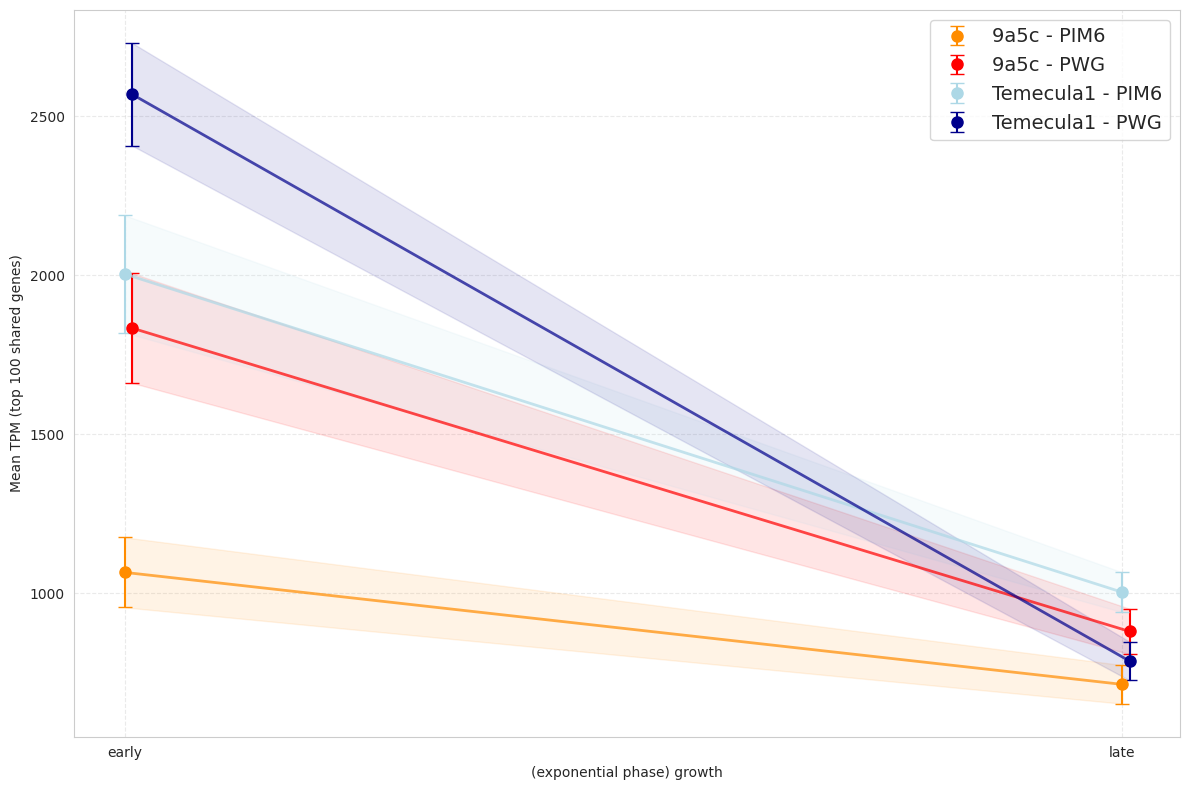

Genes used in final plot: 100
Of these, FDR-significant genes: 100


In [16]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd


def process_data(top_n_genes=100, alpha=0.05):
    """
    Figure 4A pipeline (Option A):

    - Collapse orthologs to a single unified_gene_name.
    - Keep only shared orthologs (present in gene_dictionary).
    - Build a long table: unified_gene_name × strain × condition × replicate.
    - Run per-gene ANOVA: tpm ~ C(strain_condition).
    - FDR-correct p-values across genes (Benjamini–Hochberg).
    - Select genes as:
        1) all genes with pFDR < alpha, sorted by mean TPM (descending),
        2) if fewer than top_n_genes, fill remaining slots with highest-mean-TPM
           non-significant genes until reaching top_n_genes.
    - Run Tukey HSD on the final set (across strain_condition groups).
    - Aggregate mean TPM ± SE per strain × condition for plotting.

    Returns
    -------
    top_df : long-format DataFrame (rows = gene × strain × condition × replicate)
             restricted to the final gene set used.
    agg    : aggregated DataFrame with columns:
             strain, condition, medium, phase, avg_tpm, std_tpm, n, std_error
    stats_df : DataFrame with per-gene p-values, pFDR, mean_tpm, and a 'selected' flag.
    tukey_results : statsmodels TukeyHSDResults object.
    """

    # --- 1. Load data ---
    df_9a = pd.read_csv("table_9a_b4_avg_tpm.csv", sep="\t")
    df_tem = pd.read_csv("table_tem_b4_avg_tpm.csv", sep="\t")
    dict_df = pd.read_csv("gene_dictionary.csv", sep="\t")

    # --- 2. Build unified_gene_name for ortholog pairs ---
    dict_df["unified_gene_name"] = (
        dict_df["9a5c_IMG_ID"].fillna("") + "_" +
        dict_df["Temecula1_IMG_ID"].fillna("")
    ).str.strip("_")

    # Maps: IMG ID -> unified ID
    map_9a = dict_df.set_index("9a5c_IMG_ID")["unified_gene_name"].dropna().to_dict()
    map_tem = dict_df.set_index("Temecula1_IMG_ID")["unified_gene_name"].dropna().to_dict()

    # Attach unified IDs to TPM tables and keep only shared orthologs
    df_9a["unified_gene_name"] = df_9a["Name"].map(map_9a)
    df_tem["unified_gene_name"] = df_tem["Name"].map(map_tem)
    df_9a = df_9a.dropna(subset=["unified_gene_name"])
    df_tem = df_tem.dropna(subset=["unified_gene_name"])

    # --- 3. Robust numeric conversion of TPM columns ---
    def convert_numeric_columns(df):
        for col in df.columns:
            if col not in ("Name", "unified_gene_name"):
                df[col] = (
                    df[col]
                    .astype(str)
                    .str.replace(",", ".", regex=False)
                )
                df[col] = pd.to_numeric(df[col], errors="coerce")
        return df

    df_9a = convert_numeric_columns(df_9a)
    df_tem = convert_numeric_columns(df_tem)

    # --- 4. Replicate -> condition maps (as before) ---
    condition_map_9a = {
        'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
        'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
        'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
        'PWG - late' : ['PWG - 10d - 1', 'PWG - 10d - 2', 'PWG - 10d - 3'],
    }
    condition_map_tem = {
        'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
        'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
        'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
        'PWG - late' : ['PWG - 7d - 1', 'PWG - 7d - 2', 'PWG - 7d - 3'],
    }

    # --- 5. Build long table: gene × strain × condition × replicate ---
    rows = []

    def collect_long(df, strain, cmap):
        for cond_label, cols in cmap.items():
            for _, r in df.iterrows():
                for c in cols:
                    if c in df.columns:
                        rows.append({
                            "unified_gene_name": r["unified_gene_name"],
                            "strain": strain,
                            "condition": cond_label,
                            "replicate": c,
                            "tpm": r[c],
                        })

    collect_long(df_9a, "9a5c", condition_map_9a)
    collect_long(df_tem, "Temecula1", condition_map_tem)

    long_df = pd.DataFrame(rows)

    # Ensure TPM is numeric and drop non-convertible values
    long_df["tpm"] = (
        long_df["tpm"]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    long_df["tpm"] = pd.to_numeric(long_df["tpm"], errors="coerce")
    long_df = long_df.dropna(subset=["tpm"])

    # Add strain_condition factor
    long_df["strain_condition"] = long_df["strain"] + " | " + long_df["condition"]

    # If fewer genes than requested, adjust top_n_genes downward
    n_genes_total = long_df["unified_gene_name"].nunique()
    if n_genes_total < top_n_genes:
        top_n_genes = n_genes_total

    # --- 6. For each gene: compute mean TPM & ANOVA p-value ---
    gene_stats = []

    for gene, gdf in long_df.groupby("unified_gene_name"):
        # mean TPM across all groups/replicates
        mean_tpm = gdf["tpm"].mean()

        # run ANOVA only if:
        # - there is more than one strain_condition group, AND
        # - TPM is not constant across all observations
        if gdf["strain_condition"].nunique() > 1 and gdf["tpm"].nunique() > 1:
            try:
                model = ols("tpm ~ C(strain_condition)", data=gdf).fit()
                anova_table = sm.stats.anova_lm(model, typ=2)
                pval = anova_table.loc["C(strain_condition)", "PR(>F)"]
            except Exception:
                # any weird numerical issue -> treat as non-testable
                pval = np.nan
        else:
            pval = np.nan

        gene_stats.append({
            "unified_gene_name": gene,
            "mean_tpm": mean_tpm,
            "pval_anova": pval,
        })


    # --- 7. FDR correction across genes (for those with defined p-values) ---
    mask_valid = stats_df["pval_anova"].notna()
    stats_df["pval_fdr"] = np.nan

    if mask_valid.any():
        pvals = stats_df.loc[mask_valid, "pval_anova"].values
        _, pvals_fdr, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")
        stats_df.loc[mask_valid, "pval_fdr"] = pvals_fdr

    # --- 8. Option A selection logic (significance-first, then TPM) ---

    # 8a. Significant genes (pFDR < alpha), sorted by mean TPM
    sig = stats_df[
        stats_df["pval_fdr"].notna() & (stats_df["pval_fdr"] < alpha)
    ].copy()
    sig = sig.sort_values("mean_tpm", ascending=False)

    selected_genes = list(sig["unified_gene_name"])

    # 8b. If fewer than top_n_genes, fill with highest-mean-TPM non-significant genes
    if len(selected_genes) < top_n_genes:
        non_sig = stats_df[
            ~stats_df["unified_gene_name"].isin(selected_genes)
        ].copy()
        non_sig = non_sig.sort_values("mean_tpm", ascending=False)

        for g in non_sig["unified_gene_name"]:
            selected_genes.append(g)
            if len(selected_genes) == top_n_genes:
                break
    else:
        # Optionally cut to exactly top_n_genes if there are more significant than needed
        selected_genes = selected_genes[:top_n_genes]

    # Mark selected genes in stats_df
    stats_df["selected"] = stats_df["unified_gene_name"].isin(selected_genes)

    # --- 9. Restrict long_df to selected genes ---
    top_df = long_df[long_df["unified_gene_name"].isin(selected_genes)].copy()

    # --- 10. Tukey HSD across strain_condition groups (on selected genes) ---
    tukey_results = pairwise_tukeyhsd(
        endog=top_df["tpm"],
        groups=top_df["strain_condition"],
        alpha=alpha,
    )

    # --- 11. Aggregate for plotting: mean TPM ± SE per strain × condition ---
    agg = (
        top_df.groupby(["strain", "condition"])
        .agg(
            avg_tpm=("tpm", "mean"),
            std_tpm=("tpm", "std"),
            n=("tpm", "size"),
        )
        .reset_index()
    )

    # Split condition into medium and phase (e.g. "PIM6 - early")
    agg[["medium", "phase"]] = agg["condition"].str.split(" - ", expand=True)

    # Standard error of the mean for each group
    agg["std_error"] = agg["std_tpm"] / np.sqrt(agg["n"])

    return top_df, agg, stats_df, tukey_results

import seaborn as sns
import matplotlib.pyplot as plt

def plot_expression_trends(aggregated, top_n_genes=100):
    sns.set_style("whitegrid")

    # Colors by (strain, medium)
    cm = {
        ('9a5c', 'PIM6'): '#FF8C00',   # orange
        ('9a5c', 'PWG'):  '#FF0000',   # red
        ('Temecula1', 'PIM6'): '#ADD8E6',  # light blue
        ('Temecula1', 'PWG'):  '#00008B',  # dark blue
    }

    # Jitter by medium
    jm = {'PIM6': 0.1, 'PWG': 0.1075}

    fig, ax = plt.subplots(figsize=(12, 8))

    for (st, md), col in cm.items():
        sub = aggregated[
            (aggregated['strain'] == st) &
            (aggregated['medium'] == md)
        ].sort_values('phase')

        if sub.empty:
            continue

        x = [0 + jm[md] if p == 'early' else 1 + jm[md] for p in sub['phase']]
        y = sub['avg_tpm'].values
        y_err = sub['std_error'].values

        ax.errorbar(
            x, y, yerr=y_err,
            fmt='o', color=col,
            markersize=8, capsize=5,
            label=f'{st} - {md}'
        )
        ax.plot(x, y, color=col, linestyle='-', alpha=0.7, linewidth=2)
        ax.fill_between(x, y - y_err, y + y_err, color=col, alpha=0.1)

    ax.set_xticks([0.1, 1.1])
    ax.set_xticklabels(["early", "late"])
    ax.set_xlabel("(exponential phase) growth")
    ax.set_ylabel(f"Mean TPM (top {top_n_genes} shared genes)")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(f"gene_expression_trends_top{top_n_genes}_shared.tiff",
                dpi=600, bbox_inches='tight')
    plt.show()


NUM_TOP_GENES = 100
top_df, agg, stats_df, tukey_results = process_data(top_n_genes=NUM_TOP_GENES, alpha=0.05)
plot_expression_trends(agg, top_n_genes=NUM_TOP_GENES)

# How many genes ended up in the plot?
n_final = top_df["unified_gene_name"].nunique()
print("Genes used in final plot:", n_final)

# Among them, how many are FDR-significant?
selected_stats = stats_df[stats_df["selected"]]
n_sig = (selected_stats["pval_fdr"] < 0.05).sum()
print("Of these, FDR-significant genes:", n_sig)

In [96]:
pwd

'/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/genomes_9a5c_temecula1'

In [12]:
# # ======================
# # 🔧 Step 1: Define your two gene‐groups
# # ======================

# # genes linked to sessile/insect phase
# GROUP1_GENES = [
#     "PD0058","PD0062","PD0233","PD0279","PD0406","PD0407","PD0528","PD0731",
#     "PD0744","PD0794","PD0814","PD0815","PD0816","PD0824","PD0915","PD0928",
#     "PD0986","PD1249","PD1379","PD1386","PD1391","PD1394","PD1452","PD1671",
#     "PD1678","PD1679","PD1792","PD1801","PD1984","PD2118"
# ]

# # genes linked to mobile/colonization phase
# GROUP2_GENES = [
#     "PD0023","PD0090","PD0218","PD0313","PD0502","PD0519","PD0529","PD0639",
#     "PD0657","PD0732","PD0848","PD0855","PD0950","PD0956","PD1211","PD1485",
#     "PD1611","PD1640","PD1702","PD1703","PD1826","PD1833","PD1850","PD1851",
#     "PD1856","PD1879","PD1924","PD1926","PD1964","PD2061"
# ]

# # ======================
# # 📦 Step 2: Load your data files
# # ======================

# df_9a = pd.read_csv("table_9a_b4_avg_tpm.csv", sep="\t")
# df_tem = pd.read_csv("table_tem_b4_avg_tpm.csv", sep="\t")
# dict_df = pd.read_csv("gene_dictionary.csv", sep="\t")

# # ======================
# # 🗺️ Step 3: Define condition maps
# # ======================

# condition_map_9a = {
#     'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
#     'PIM6 - late': ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
#     'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
#     'PWG - late': ['PWG - 10d - 1', 'PWG - 10d - 2', 'PWG - 10d - 3']
# }

# condition_map_tem = {
#     'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
#     'PIM6 - late': ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
#     'PWG - early': ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
#     'PWG - late': ['PWG - 7d - 1', 'PWG - 7d - 2', 'PWG - 7d - 3']
# }

# # ======================
# # 🧠 Step 4: Helper function to convert numbers
# # ======================

# def convert_number(x):
#     if isinstance(x, str):
#         return float(x.replace(',', '.'))
#     return float(x)

# # ======================
# # 🧬 Step 5: Function to process shared genes (Top-N)
# # ======================

# # Process your PDxxxx genes
# pd_df = extrair_tpm_por_gene_tag(
#     GENES_OF_INTEREST,
#     dict_df,
#     df_tem,
#     df_9a,
#     condition_map_tem,
#     condition_map_9a
# )

# # Aggregate by condition and strain for plotting
# pd_df_grouped = pd_df.groupby(['strain', 'condition']).agg({
#     'avg_tpm': ['sum', 'count'],
#     'std_tpm': 'mean'
# }).reset_index()

# pd_df_grouped.columns = ['strain', 'condition', 'total_tpm', 'gene_count', 'mean_std']
# pd_df_grouped['avg_tpm_per_gene'] = pd_df_grouped['total_tpm'] / pd_df_grouped['gene_count']
# pd_df_grouped['std_error'] = pd_df_grouped['mean_std'] * np.sqrt(pd_df_grouped['gene_count'])
# pd_df_grouped[['medium', 'phase']] = pd_df_grouped['condition'].str.split(' - ', expand=True)

# # Now plot:
# # plot_expression_trends(pd_df_grouped, title_suffix='(Selected PD Genes)')


# # ======================
# # 🧬 Step 6: Function to extract TPMs for PDxxxx genes
# # ======================

# def extrair_tpm_por_gene_tag(genes_of_interest, dict_df, df_tem, df_9a, condition_map_tem, condition_map_9a):
#     genes_of_interest_set = set(genes_of_interest)

#     filtered_dict_df = dict_df[dict_df['Temecula1_old_locus_tags'].apply(
#         lambda tags: any(tag.replace('_', '') in genes_of_interest_set for tag in str(tags).split())
#     )]

#     gene_id_map = {}
#     for _, row in filtered_dict_df.iterrows():
#         old_tags = str(row['Temecula1_old_locus_tags']).split()
#         for tag in old_tags:
#             clean_tag = tag.replace('_', '')
#             if clean_tag in genes_of_interest_set:
#                 gene_id_map[clean_tag] = (row['Temecula1_IMG_ID'], row['9a5c_IMG_ID'])

#     results = []

#     for gene_tag, (tem_img_id, _9a_img_id) in gene_id_map.items():
#         for strain, df, cond_map, gene_id in [
#             ('Temecula1', df_tem, condition_map_tem, tem_img_id),
#             ('9a5c', df_9a, condition_map_9a, _9a_img_id)
#         ]:
#             if gene_id not in df['Name'].values:
#                 continue

#             row = df[df['Name'] == gene_id].iloc[0]
#             product = row.get('Gene Product Name', '')

#             for cond_name, replicas in cond_map.items():
#                 values = [convert_number(row[r]) for r in replicas if r in df.columns]
#                 values = [v for v in values if not np.isnan(v)]
#                 if values:
#                     avg = np.mean(values)
#                     std = np.std(values)
#                     results.append({
#                         'gene_tag': gene_tag,
#                         'strain': strain,
#                         'gene_id': gene_id,
#                         'product': product,
#                         'condition': cond_name,
#                         'avg_tpm': avg,
#                         'std_tpm': std
#                     })
#     return pd.DataFrame(results)


# # ======================
# # 🧪 Step 7-bis: Process both groups and tag them
# # ======================

# agg1 = process_data_fixed_genes(GROUP1_GENES)
# agg1['group'] = 'sessile'

# agg2 = process_data_fixed_genes(GROUP2_GENES)
# agg2['group'] = 'mobile'

# # combine
# aggregated = pd.concat([agg1, agg2], axis=0).reset_index(drop=True)

# # ======================
# # 📊 Step 8-bis: Plot with different line‐styles
# # ======================

# def plot_expression_trends(aggregated, title_suffix=''):
#     title = f"TPM Expression Trends {title_suffix}"
#     fig, ax = plt.subplots(figsize=(12, 8))
#     sns.set_style("whitegrid")

#     # color map as before
#     condition_colors = {
#         ('9a5c', 'PIM6'): '#FF8C00',
#         ('9a5c', 'PWG'): '#FF0000',
#         ('Temecula1', 'PIM6'): '#ADD8E6',
#         ('Temecula1', 'PWG'): '#00008B'
#     }
#     # line‐style per group
#     linestyle_map = {
#         'sessile': '--',
#         'mobile': ':'
#     }
#     jitter_map = {'PIM6': +0.05, 'PWG': -0.05}

#     for (strain, medium, group), subset in aggregated.groupby(['strain','medium','group']):
#         subset = subset.sort_values('phase')
#         if subset.empty: continue

#         # x positions
#         xs = [0 + jitter_map[medium] if p=='early' else 1 + jitter_map[medium]
#               for p in subset['phase']]

#         ys = subset['avg_tpm_per_gene']
#         yerr = subset['std_error']
#         color = condition_colors[(strain, medium)]
#         ls = linestyle_map[group]

#         # points + error bars
#         ax.errorbar(xs, ys, yerr=yerr, fmt='o', color=color, capsize=5)
#         # dashed vs dotted line
#         ax.plot(xs, ys, color=color, linestyle=ls, linewidth=2,
#                 label=f"{strain}‒{medium} [{group}]")

#     ax.set_xticks([0,1])
#     ax.set_xticklabels(['Early', 'Late'])
#     ax.set_xlabel('Growth phase')
#     ax.set_ylabel('Mean TPM per gene')
#     # ax.legend(bbox_to_anchor=(1,1), fontsize=12)
#     ax.legend(fontsize=12)
#     # Add grid lines
#     ax.grid(True, linestyle='--', alpha=0.4)
#     plt.tight_layout()
#     plt.savefig('virulence_genes_gene_expression_trends.tiff', dpi=600, bbox_inches='tight')
#     plt.show()

# # finally call:
# plot_expression_trends(aggregated, title_suffix='(Both Groups)')


Number of virulence genes used per group and strain:
group    strain   
mobile   9a5c         41
         Temecula1    42
sessile  9a5c         31
         Temecula1    32
Name: gene_tag, dtype: int64


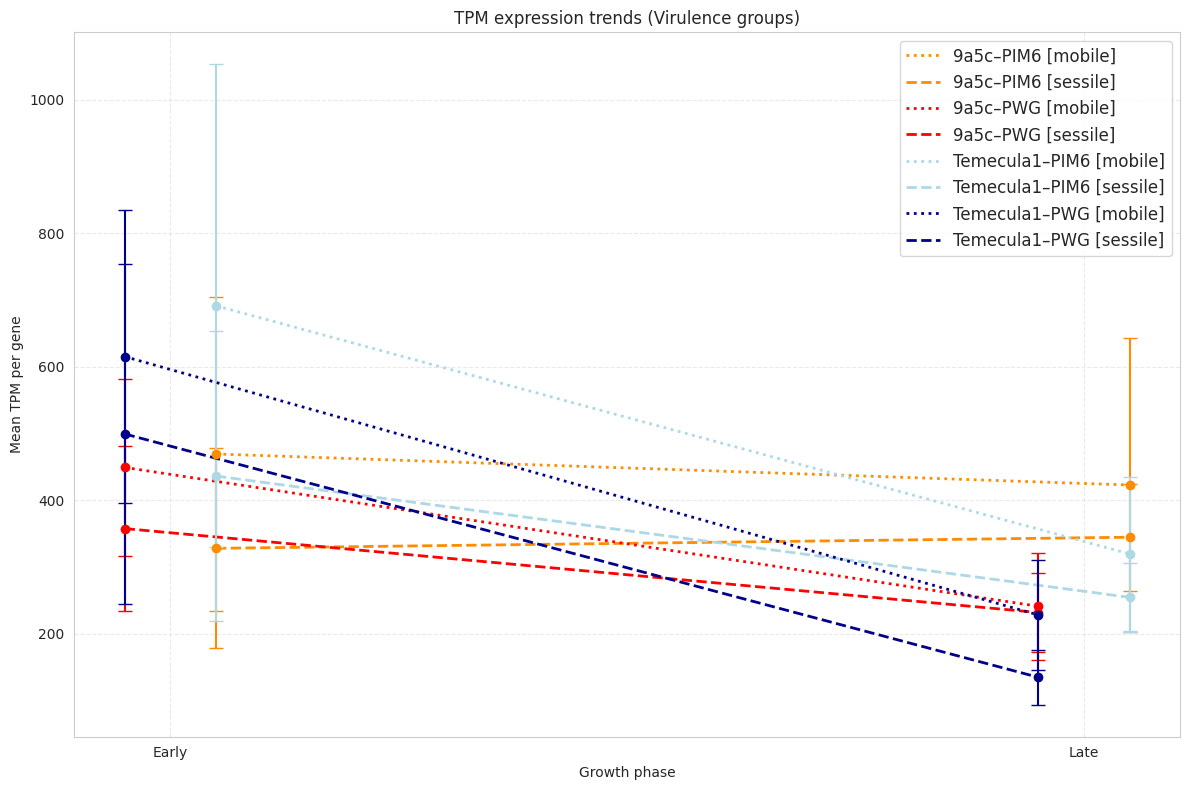

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ======================
# 1. File paths
# ======================

VIR_TABLE = "virulence_table.csv"
TPM_9A    = "table_9a_b4_avg_tpm.csv"
TPM_TEM   = "table_tem_b4_avg_tpm.csv"
DICT_FILE = "gene_dictionary.csv"

# ======================
# 2. Condition maps (same as before)
# ======================

condition_map_9a = {
    'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
    'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
    'PWG - early' : ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
    'PWG - late'  : ['PWG - 10d - 1', 'PWG - 10d - 2', 'PWG - 10d - 3'],
}

condition_map_tem = {
    'PIM6 - early': ['PIM6 - 1d - 1', 'PIM6 - 1d - 2', 'PIM6 - 1d - 3'],
    'PIM6 - late' : ['PIM6 - 3d - 1', 'PIM6 - 3d - 2', 'PIM6 - 3d - 3'],
    'PWG - early' : ['PWG - 3d - 1', 'PWG - 3d - 2', 'PWG - 3d - 3'],
    'PWG - late'  : ['PWG - 7d - 1', 'PWG - 7d - 2', 'PWG - 7d - 3'],
}

# ======================
# 3. Helper: numeric conversion
# ======================

def convert_number(x):
    if isinstance(x, str):
        x = x.replace(",", ".")
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

# ======================
# 4. Read virulence table and split into groups
# ======================

def load_virulence_groups(vir_table_path):
    """
    Uses 'phase expression' from virulence_table.csv to define:
      1 -> 'mobile' (colonization phase)
      2 -> 'sessile' (insect phase)
      0 -> ignored for Figure 4B
    Returns:
      dict: {'mobile': [PD...], 'sessile': [PD...]}
    """
    # Try UTF-8 first, fall back to Latin-1 if needed
    try:
        vdf = pd.read_csv(vir_table_path, sep=None, engine="python", encoding="utf-8")
    except UnicodeDecodeError:
        vdf = pd.read_csv(vir_table_path, sep=None, engine="python", encoding="latin1")

    # Column names from your example:
    # 'Gene ID', 'Gene', 'Description', 'Function',
    # 'Number of genomes with intact gene', 'phase expression'
    phase_col = [c for c in vdf.columns if "phase" in c.lower()][0]
    geneid_col = [c for c in vdf.columns if "gene id" in c.lower()][0]

    # Map 1 -> mobile, 2 -> sessile, 0 -> ignore
    mobile = vdf.loc[vdf[phase_col] == 1, geneid_col].astype(str).tolist()
    sessile = vdf.loc[vdf[phase_col] == 2, geneid_col].astype(str).tolist()

    return {"mobile": mobile, "sessile": sessile}

# ======================
# 5. Map PD tags -> IMG IDs using gene_dictionary.csv
# ======================

def build_pd_to_img_map(dict_df):
    """
    Returns dict:
      PD_tag (e.g. 'PD0023') ->
          (Tem_IMG_ID, 9a_IMG_ID)
    based on Temecula1_old_locus_tags and IMG_ID columns.
    """
    pd_to_img = {}

    for _, row in dict_df.iterrows():
        old_tags = str(row.get("Temecula1_old_locus_tags", "")).split()
        tem_img = row.get("Temecula1_IMG_ID", np.nan)
        x9a_img = row.get("9a5c_IMG_ID", np.nan)

        for tag in old_tags:
            clean_tag = tag.replace("_", "")
            if clean_tag.startswith("PD"):
                pd_to_img.setdefault(clean_tag, (tem_img, x9a_img))

    return pd_to_img

# ======================
# 6. Extract TPM for a set of PD genes (one group)
# ======================

def extract_tpm_for_pd_genes(pd_genes, dict_df, df_tem, df_9a,
                             condition_map_tem, condition_map_9a,
                             group_label):
    """
    Returns long-format DataFrame with:
      gene_tag, group, strain, gene_id, product, condition, avg_tpm, std_tpm
    """
    genes_of_interest_set = set(pd_genes)

    pd_to_img = build_pd_to_img_map(dict_df)

    results = []

    for gene_tag in genes_of_interest_set:
        if gene_tag not in pd_to_img:
            continue
        tem_img_id, x9a_img_id = pd_to_img[gene_tag]

        for strain, df, cond_map, gene_id in [
            ("Temecula1", df_tem, condition_map_tem, tem_img_id),
            ("9a5c",      df_9a,  condition_map_9a,  x9a_img_id),
        ]:
            if pd.isna(gene_id) or gene_id not in df["Name"].values:
                continue

            row = df.loc[df["Name"] == gene_id].iloc[0]
            # Try to find a reasonable product column name
            prod_col_candidates = [c for c in df.columns if "product" in c.lower()]
            product = row[prod_col_candidates[0]] if prod_col_candidates else ""

            for cond_name, reps in cond_map.items():
                vals = [convert_number(row[r]) for r in reps if r in df.columns]
                vals = [v for v in vals if not np.isnan(v)]

                if not vals:
                    continue

                avg = float(np.mean(vals))
                std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0

                results.append({
                    "gene_tag": gene_tag,
                    "group": group_label,          # "mobile" or "sessile"
                    "strain": strain,
                    "gene_id": gene_id,
                    "product": product,
                    "condition": cond_name,
                    "avg_tpm": avg,
                    "std_tpm": std,
                })

    return pd.DataFrame(results)

# ======================
# 7. Aggregate by strain × medium × phase × group
# ======================

def aggregate_group_expression(pd_df):
    """
    Takes the long table (per-gene avg_tpm) and returns
    per (strain, medium, phase, group):
        - mean TPM per gene
        - SE across genes
        - gene_count
    """
    if pd_df.empty:
        return pd.DataFrame()

    # Split condition -> medium, phase
    pd_df[["medium", "phase"]] = pd_df["condition"].str.split(" - ", expand=True)

    # One observation per gene per strain/condition/group: avg_tpm
    # Treat each gene as a replicate within its group
    agg = (
        pd_df.groupby(["strain", "medium", "phase", "group"])
        .agg(
            mean_tpm_per_gene=("avg_tpm", "mean"),
            sd_across_genes=("avg_tpm", "std"),
            gene_count=("gene_tag", "nunique"),
        )
        .reset_index()
    )

    # Standard error of mean across genes
    agg["std_error"] = agg["sd_across_genes"] / np.sqrt(agg["gene_count"].clip(lower=1))

    # For convenience in plotting
    agg["avg_tpm_per_gene"] = agg["mean_tpm_per_gene"]

    return agg

# ======================
# 8. Main wrapper to prepare Figure 4B data
# ======================

def prepare_figure4B_data():
    # Load all source tables
    vir_groups = load_virulence_groups(VIR_TABLE)
    df_9a = pd.read_csv(TPM_9A, sep="\t")
    df_tem = pd.read_csv(TPM_TEM, sep="\t")
    dict_df = pd.read_csv(DICT_FILE, sep="\t")

    # Convert all numeric TPM-ish columns to proper floats first
    def fix_numeric(df):
        for col in df.columns:
            if col not in ("Name",):
                df[col] = df[col].apply(convert_number)
        return df

    df_9a = fix_numeric(df_9a)
    df_tem = fix_numeric(df_tem)

    # Mobile (phase 1)
    mob_genes = vir_groups["mobile"]
    sess_genes = vir_groups["sessile"]

    mob_df = extract_tpm_for_pd_genes(
        mob_genes, dict_df, df_tem, df_9a,
        condition_map_tem, condition_map_9a,
        group_label="mobile"
    )

    sess_df = extract_tpm_for_pd_genes(
        sess_genes, dict_df, df_tem, df_9a,
        condition_map_tem, condition_map_9a,
        group_label="sessile"
    )

    joined = pd.concat([mob_df, sess_df], axis=0).reset_index(drop=True)
    aggregated = aggregate_group_expression(joined)

    # Just to know how many genes per group actually mapped and were used:
    used_counts = joined.groupby(["group", "strain"])["gene_tag"].nunique()
    print("Number of virulence genes used per group and strain:")
    print(used_counts)

    return joined, aggregated

def plot_expression_trends_virulence(aggregated, title_suffix="(Virulence groups)"):
    """
    Plots mean TPM per gene ± SE for sessile vs mobile virulence groups.
    Colors: strain × medium
    Line style: group (sessile dashed, mobile dotted)
    """
    sns.set_style("whitegrid")

    fig, ax = plt.subplots(figsize=(12, 8))

    # Colors by (strain, medium) – consistent with Figure 4A
    condition_colors = {
        ('9a5c',      'PIM6'): '#FF8C00',  # orange
        ('9a5c',      'PWG') : '#FF0000',  # red
        ('Temecula1', 'PIM6'): '#ADD8E6',  # light blue
        ('Temecula1', 'PWG') : '#00008B',  # dark blue
    }

    # Line style per virulence group
    linestyle_map = {
        'sessile': '--',
        'mobile':  ':',
    }

    # Small jitter so PIM6 and PWG don't overlap
    jitter_map = {'PIM6': +0.05, 'PWG': -0.05}

    for (strain, medium, group), subset in aggregated.groupby(["strain", "medium", "group"]):
        subset = subset.sort_values("phase")
        if subset.empty:
            continue

        xs = [0 + jitter_map[medium] if p.lower() == "early" else 1 + jitter_map[medium]
              for p in subset["phase"]]

        ys = subset["avg_tpm_per_gene"].values
        yerr = subset["std_error"].values

        color = condition_colors[(strain, medium)]
        ls = linestyle_map.get(group, "-")

        ax.errorbar(xs, ys, yerr=yerr, fmt='o', color=color, capsize=5)
        ax.plot(xs, ys, color=color, linestyle=ls, linewidth=2,
                label=f"{strain}–{medium} [{group}]")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Early", "Late"])
    ax.set_xlabel("Growth phase")
    ax.set_ylabel("Mean TPM per gene")
    ax.set_title(f"TPM expression trends {title_suffix}")

    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig("virulence_genes_gene_expression_trends_new.tiff",
                dpi=600, bbox_inches="tight")
    plt.show()

    
joined_vir, agg_vir = prepare_figure4B_data()
plot_expression_trends_virulence(agg_vir)

In [3]:
# Cell: build heatmap of virulence genes across comparisons
import math, traceback
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
import re

In [5]:
# ---------------------- USER PARAMETERS ----------------------
WORKDIR = Path("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2")
# C:\Users\oseia\OneDrive\pierry_paper\Paper transcritoma 9a5c e Tem1-maio22\Paper transcritoma 9a5c e Tem1-maio22\DeSeq2
# C:\Users\oseia\OneDrive\pierry_paper\Paper transcritoma 9a5c e Tem1-maio22\Paper transcritoma 9a5c e Tem1-maio22\DeSeq2
OUTDIR = WORKDIR / "DESeq2_results"
FORMATTED_SUMMARY = OUTDIR / "comparisons_summary_formatted.csv"  # produced by your pipeline

# path to virulence table (CSV/TSV). If you already have it loaded as a DataFrame (vir_df),
# you can skip reading from disk; otherwise set path_to_virfile appropriately.
path_to_virfile = WORKDIR / "virulence_table.csv"   # <- update if needed; see notes below

# Save path for the clustermap figure
out_heatmap = OUTDIR / "virulence_genes_clustermap.tiff"

In [6]:
# Add after WORKDIR definition in Cell 1
DICT_PATH = WORKDIR / "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/gene_dictionary.csv"
if not DICT_PATH.exists():
    raise FileNotFoundError(f"Gene mapping dictionary not found at {DICT_PATH}")
    
# Load dictionary
dict_df = pd.read_csv(DICT_PATH, sep='\t')
print(f"Loaded gene mapping dictionary with {len(dict_df)} entries")

Loaded gene mapping dictionary with 1831 entries


In [7]:
# ---------------------- helper functions ----------------------
def choose_old_tag(s):
    """From a string of old locus tags (e.g. "PD1497 PD_1497" or "PD1497\tPD_1497"),
       choose the one without underscore if present, else first token."""
    if pd.isna(s) or s is None:
        return None
    parts = re.split(r'[\s,;|]+', str(s).strip())
    if not parts:
        return None
    for p in parts:
        if "_" not in p and p != "":
            return p
    for p in parts:
        if p != "":
            return p
    return None

def load_virulence_table(path: Path):
    """
    Load virulence table. Accepts CSV/TSV. If path doesn't exist, try to fall back to a minimal
    manually-provided example (but ideally you save the table to path_to_virfile).
    The expected columns (any close match) are:
      - Gene ID in Temecula1 strain (e.g. 'PD0058')  [we will search for 'PD' pattern]
      - Gene (short name) optional
      - Description
      - Function (used for column colors)
    """
    if path.exists():
        # try common separators
        try:
            df = pd.read_csv(path, sep=None, engine='python')  # autodetect sep
        except Exception:
            df = pd.read_csv(path, sep=",", engine="python")
    else:
        raise FileNotFoundError(f"Virulence table not found at {path}. Please save your virulence table as CSV and set 'path_to_virfile'.")
    # normalize column names
    cols = {c: c.strip() for c in df.columns}
    df = df.rename(columns=cols)
    # try to find a column that looks like the gene ID (e.g. starts with PD or matches PD\d+)
    gene_col = None
    for c in df.columns:
        # heuristics: contains 'Gene ID' or 'Temecula' or cells look like PD####.
        if 'gene id' in c.lower() or 'temecula' in c.lower() or 'pd' in c.lower():
            gene_col = c
            break
    if gene_col is None:
        # fallback: find a column where most entries match PD\d+
        for c in df.columns:
            sample = df[c].dropna().astype(str).head(30).tolist()
            if sum(1 for s in sample if re.match(r'PD\d+', s.strip())) >= len(sample) / 3:
                gene_col = c
                break
    if gene_col is None:
        raise RuntimeError("Could not find a column with Temecula1 gene IDs (PD#####) in the virulence table. Please ensure a column exists.")
    # canonicalize columns
    df = df.rename(columns={gene_col: 'tem_gene_id'})
    # ensure functions and descriptions exist
    if 'Function' not in df.columns:
        # try other names
        for c in df.columns:
            if 'function' in c.lower():
                df = df.rename(columns={c: 'Function'})
                break
    if 'Description' not in df.columns:
        for c in df.columns:
            if 'description' in c.lower() or 'desc' in c.lower():
                df = df.rename(columns={c: 'Description'})
                break
    df['tem_gene_id'] = df['tem_gene_id'].astype(str).str.strip()
    df['Function'] = df.get('Function', pd.Series(['Unknown'] * len(df))).fillna('Unknown')
    df['Description'] = df.get('Description', pd.Series([''] * len(df))).fillna('')
    return df[['tem_gene_id','Function','Description']].drop_duplicates().reset_index(drop=True)

# ---------------------- prepare mapping dicts if dict_df present ----------------------
# dict_df is expected to have columns like '9a5c_IMG_ID','9a5c_old_locus_tags','Temecula1_IMG_ID','Temecula1_old_locus_tags'
map_img_to_tem_old = {}   # map IMG ID (either strain) -> Temecula1 old locus tag (PD####),
map_img_to_9a_old = {}    # map IMG ID -> 9a5c old locus tag (e.g., XF####)
if 'dict_df' in globals():
    _df = dict_df.copy()
    # normalize column names (if slight differences exist)
    # attempt mappings
    if 'Temecula1_IMG_ID' in _df.columns and 'Temecula1_old_locus_tags' in _df.columns:
        for img, old in zip(_df['Temecula1_IMG_ID'], _df['Temecula1_old_locus_tags']):
            if pd.notna(img):
                tag = choose_old_tag(old)
                if tag:
                    map_img_to_tem_old[str(img)] = tag
    if '9a5c_IMG_ID' in _df.columns and '9a5c_old_locus_tags' in _df.columns:
        for img, old in zip(_df['9a5c_IMG_ID'], _df['9a5c_old_locus_tags']):
            if pd.notna(img):
                tag = choose_old_tag(old)
                if tag:
                    map_img_to_9a_old[str(img)] = tag
    # also create mapping 9a_img -> tem_old if both columns present (for cross-strain conversion)
    if '9a5c_IMG_ID' in _df.columns and 'Temecula1_old_locus_tags' in _df.columns:
        for a,b in zip(_df['9a5c_IMG_ID'], _df['Temecula1_old_locus_tags']):
            if pd.notna(a) and pd.notna(b):
                tag = choose_old_tag(b)
                if tag:
                    map_img_to_tem_old[str(a)] = tag
    if 'Temecula1_IMG_ID' in _df.columns and '9a5c_old_locus_tags' in _df.columns:
        for a,b in zip(_df['Temecula1_IMG_ID'], _df['9a5c_old_locus_tags']):
            if pd.notna(a) and pd.notna(b):
                tag = choose_old_tag(b)
                if tag:
                    map_img_to_9a_old[str(a)] = tag

# If the dict wasn't present, maps stay empty; the script will try to use per-comparison annotated files first.

# ---------------------- load virulence table ----------------------
vir_df = load_virulence_table(Path(path_to_virfile))
vir_genes = vir_df['tem_gene_id'].tolist()
print(f"Loaded {len(vir_df)} virulence genes (Temecula1 IDs), example: {vir_genes[:5]}")

# ---------------------- collect comparisons ----------------------
if FORMATTED_SUMMARY.exists():
    formatted = pd.read_csv(FORMATTED_SUMMARY)
    # find columns that contain Condition 1 and Condition 2
    c1_col = next((c for c in formatted.columns if 'Condition 1' in c), None)
    c2_col = next((c for c in formatted.columns if 'Condition 2' in c), None)
    if c1_col is None or c2_col is None:
        raise RuntimeError("Formatted summary does not contain 'Condition 1'/'Condition 2' columns.")
    comparisons = [(r[c1_col], r[c2_col]) for _, r in formatted[[c1_col,c2_col]].iterrows()]
else:
    # fallback: find subfolders in OUTDIR with _vs_
    comparisons = []
    for p in sorted(OUTDIR.iterdir()):
        if p.is_dir() and "_vs_" in p.name:
            a,b = p.name.split("_vs_",1)
            comparisons.append((a,b))

print(f"Found {len(comparisons)} comparisons to scan.")

# ---------------------- iterate comps and build matrix ----------------------
# We'll produce a DataFrame: index=comparison_name, columns=vir_genes, values=log2FoldChange
matrix = pd.DataFrame(index=[f"{a}_vs_{b}" for a,b in comparisons], columns=vir_genes, dtype=float).fillna(0.0)

# helper to map a gene_id (from DESeq2_results_full.csv 'gene_id' column) to Temecula1 old locus tag if possible
def map_result_geneid_to_tem_old(gene_id, comp_folder):
    """Try multiple strategies:
       1) Look for DEGs_annotated file in comp_folder that maps gene_id->old_locustag (we used that earlier)
       2) Use global dict maps: map_img_to_tem_old or map_img_to_9a_old to infer mapping
       3) Try heuristics (if gene_id looks already like PD#### return it)
    """
    gid = str(gene_id)
    # heuristic: if already a PD#### return
    if re.match(r'PD\d+', gid):
        return gid
    # 1) try local annotated file (if exists) - these map gene_id -> old_locustag in your pipeline
    try:
        # find any annotated file in comp folder
        ann_files = list(Path(comp_folder).glob("DEGs_annotated_*.csv"))
        if ann_files:
            ann = pd.read_csv(ann_files[0])
            if 'gene_id' in ann.columns and 'old_locustag' in ann.columns:
                row = ann.loc[ann['gene_id'].astype(str) == gid]
                if not row.empty:
                    val = str(row['old_locustag'].iloc[0]).strip()
                    if val:
                        return val
    except Exception:
        pass
    # 2) try global dict maps created above
    if gid in map_img_to_tem_old:
        return map_img_to_tem_old[gid]
    if gid in map_img_to_9a_old:
        # map 9a->tem if available in map_img_to_tem_old by using mapping in dict_df (some constructed earlier)
        # if no direct tem mapping exists, return 9a old tag (not ideal)
        tem = map_img_to_tem_old.get(gid)
        if tem:
            return tem
        return map_img_to_9a_old[gid]
    # 3) try to detect if gid contains 'XF' or 'PD' prefixes and map using dict_df lookups
    if 'dict_df' in globals():
        # try to match on any IMG ID columns
        df = dict_df
        if '9a5c_IMG_ID' in df.columns and gid in df['9a5c_IMG_ID'].values:
            idx = df.index[df['9a5c_IMG_ID'] == gid][0]
            val = choose_old_tag(df.loc[idx, 'Temecula1_old_locus_tags'] if 'Temecula1_old_locus_tags' in df.columns else df.loc[idx, 'Temecula1_IMG_ID'])
            if val:
                return val
        if 'Temecula1_IMG_ID' in df.columns and gid in df['Temecula1_IMG_ID'].values:
            idx = df.index[df['Temecula1_IMG_ID'] == gid][0]
            val = choose_old_tag(df.loc[idx, 'Temecula1_old_locus_tags']) if 'Temecula1_old_locus_tags' in df.columns else None
            if val:
                return val
    # nothing found
    return None

# loop comparisons
for a,b in comparisons:
    comp_name = f"{a}_vs_{b}"
    comp_folder = OUTDIR / comp_name
    if not comp_folder.exists():
        print(f"WARNING: folder missing for comparison {comp_name}, skipping.")
        continue

    # load DESeq2 results full (contains gene_id, log2FoldChange)
    result_file = comp_folder / "DESeq2_results_full.csv"
    if not result_file.exists():
        # sometimes file was named differently, try to find any DESeq2_results_full*.csv
        cand = list(comp_folder.glob("DESeq2_results_full*.csv"))
        if cand:
            result_file = cand[0]
        else:
            print(f"WARNING: no DESeq2_results_full.csv in {comp_folder}, skipping.")
            continue

    try:
        res = pd.read_csv(result_file)
    except Exception as e:
        print(f"ERROR reading {result_file}: {e}")
        continue

    # ensure gene_id column exists; if not perhaps first column is gene id
    if 'gene_id' not in res.columns:
        # try to find a non-numeric first column
        first_col = res.columns[0]
        res = res.rename(columns={first_col: 'gene_id'})
    # get mapping gene_id -> log2FoldChange (might be NaN)
    if 'log2FoldChange' in res.columns:
        res_map = res.set_index('gene_id')['log2FoldChange'].to_dict()
    elif 'log2FoldChange' not in res.columns and 'log2FoldChange' in res.columns.str.lower():
        # try case-insensitive
        col = next(c for c in res.columns if 'log2foldchange' in c.lower())
        res_map = res.set_index('gene_id')[col].to_dict()
    else:
        # if not present, try 'foldChange' or any close name
        candidate = next((c for c in res.columns if 'log2' in c.lower() and 'fold' in c.lower()), None)
        if candidate:
            res_map = res.set_index('gene_id')[candidate].to_dict()
        else:
            # if no fold-change available, skip
            print(f"WARNING: no log2FoldChange/fold column in {result_file} for {comp_name}; skipping.")
            continue

    # now for each gene in the virulence list, look up its log2FC in res_map after mapping gene ids
    for vg in vir_genes:
        matched_value = None
        # first: if vir gene is directly present as gene_id (e.g. Temecula1 mapping used in this comp)
        if vg in res_map:
            matched_value = res_map[vg]
        else:
            # else try to find any result gene that maps to this VG via mapping function
            # iterate over a few entries in res_map until match found (inefficient but comparisons are limited)
            for gid, l2fc in res_map.items():
                mapped = map_result_geneid_to_tem_old(gid, comp_folder)
                if mapped == vg:
                    matched_value = l2fc
                    break
        # if matched_value is still None: leave as 0.0 (means not differential or not present)
        if matched_value is None or (isinstance(matched_value, float) and (np.isnan(matched_value))):
            matrix.at[comp_name, vg] = 0.0
        else:
            matrix.at[comp_name, vg] = float(matched_value)

# ---------------------- Prepare annotation and plotting ----------------------
# create column-level metadata (Function) from vir_df
col_meta = vir_df.set_index('tem_gene_id').reindex(matrix.columns)
# any missing functions become 'Unknown'
col_meta['Function'] = col_meta['Function'].fillna('Unknown')

# color map for functional groups
unique_groups = col_meta['Function'].unique().tolist()
palette = sns.color_palette("tab20", n_colors=max(2, len(unique_groups)))
group_colors = dict(zip(unique_groups, palette))
col_colors = pd.Series([group_colors.get(col_meta.loc[g,'Function'], '#cccccc') for g in matrix.columns], index=matrix.columns)

# Optional: order columns (genes) by group to keep the clustermap tidy
# and optionally remove genes that are all zeros (never observed)
nonzero_cols = matrix.columns[(matrix.abs().sum(axis=0) > 0)]
if len(nonzero_cols) == 0:
    print("No virulence genes showed non-zero fold changes across comparisons. The matrix will be empty.")
# Subset matrix to only virulence genes present in data (or keep all if you prefer)
matrix_plot = matrix.loc[:, list(nonzero_cols)].copy()
if matrix_plot.shape[1] == 0:
    # fallback: include all vir genes (will just be zeros)
    matrix_plot = matrix.copy()

# build clustermap
sns.set(font_scale=0.8)
# custom diverging colormap centered at 0
cmap = LinearSegmentedColormap.from_list("custom_div", ["#2c7bb6", "#d9d9d9", "#b2182b"])  # blue->gray->red
g = sns.clustermap(matrix_plot,
                   cmap=cmap,
                   col_cluster=True,
                   row_cluster=True,
                   linewidths=0.0,
                   figsize=(14, max(6, 0.4 * matrix_plot.shape[0])),
                   center=0,
                   col_colors=[col_colors[c] for c in matrix_plot.columns] if matrix_plot.shape[1]>0 else None,
                   xticklabels=True,
                   yticklabels=True)

# Format labels
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# Add legend for function groups
handles = [Patch(facecolor=group_colors[k], label=k) for k in group_colors]
# place the legend outside the heatmap (below)
g.ax_col_dendrogram.legend(handles=handles,
                           title='Function',
                           loc='center left',
                           bbox_to_anchor=(1.05, 0.5),
                           fontsize='small')

# reposition colorbar (small and vertical on right)
cax = g.cax
cax.set_position([0.92, 0.2, 0.02, 0.5])  # [x0,y0,width,height] in figure fraction coordinates

# save
plt.savefig(out_heatmap, dpi=600, bbox_inches='tight')
plt.show()

print("Heatmap saved to:", out_heatmap)

Loaded 71 virulence genes (Temecula1 IDs), example: ['PD0023', 'PD0058', 'PD0062', 'PD0090', 'PD0218']
Found 12 comparisons to scan.


KeyboardInterrupt: 